# Motion-Phase ML: End-to-End Workflow

# Motion-Phase ML: End-to-End Workflow

## Notebook Guide
- **Part 1: Dataset Overview:** quick health checks, class balance, and sensor visualizations.
- **Part 2: Preprocessing:** duplicate removal, timestamp cleanup, sampling-rate diagnostics, and segmentation.
- **Part 3: Feature Engineering:** engineered statistics and spectral features, feature ranking, and artifact generation for modeling.
- **Part 4: Model Training and Hyperparameter Tuning:** model selection, pipeline setup, cross-validation, GridSearchCV tuning, and saving trained models.


## Setup and Configuration

This section imports all required libraries and defines global settings used throughout the notebook. It covers:
- Data handling and plotting libraries for analysis and diagnostics.
- Signal processing and feature-selection tools .
- Reproducible output paths and constants.

In [279]:
modules = {
    "pathlib": "pathlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
}

print(f"{'Module':<20} {'Status':<12} {'Version'}")
print("-" * 50)

for module, package in modules.items():
    try:
        mod = __import__(module)
        version = getattr(mod, "__version__", "n/a")
        print(f"{module:<20} {'✅ Installed':<12} {version}")
    except ImportError:
        print(f"{module:<20} {'❌ Missing':<12} pip install {package}")

Module               Status       Version
--------------------------------------------------
pathlib              ✅ Installed  n/a
numpy                ✅ Installed  2.2.5
pandas               ✅ Installed  2.3.3
matplotlib           ✅ Installed  3.10.8
seaborn              ✅ Installed  0.13.2
scipy                ✅ Installed  1.15.3
sklearn              ✅ Installed  1.7.2


In [280]:
import sys
!{sys.executable} -m pip install seaborn
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import rfft, rfftfreq
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8")
sns.set_palette("crest")

In [281]:

DATA_PATH = Path("biosensor_dataset_with_target.csv")
print(f"Using dataset at: {DATA_PATH.resolve()}")

Using dataset at: /Users/nurislamsaliev/biosensor_dataset_with_target.csv


In [401]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")

print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(df_raw.info())
print(df_raw.columns.tolist())
print(f"Total athletes : {df_raw['Athlete_ID'].nunique()}")

Rows: 1,500  |  Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   object        
 8   Timestamp    1500 non-null   datetime64[ns]
 9   Athlete_ID   1500 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 117.3+ KB
None
['Heart_Rate', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Event_Label', 'Timestamp', 'Athlete_ID']
Total athletes : 5


### Runtime Parameters and Output Paths

In [283]:
OUT_DIR = Path("out")
FEATURE_OUT_DIR = OUT_DIR / "feature_engineering"
PLOT_DIR = FEATURE_OUT_DIR / "plots"

WINDOW_SECONDS = 5.0
STEP_RATIO = 0.20
STEP_SECONDS = WINDOW_SECONDS * STEP_RATIO
TOP_K = 40

LABEL_SMOOTH_WINDOW = 3
MIN_LABEL_PURITY = 0.6
USE_PURITY_FILTER_FOR_FEATURES = False
MIN_FEATURE_SAMPLES = 4

SANITY_THRESHOLDS = {
    "Heart_Rate": (60.0, 190.0),
    "Acc_X": (-3.2, 3.2),
    "Acc_Y": (-3.2, 3.2),
    "Acc_Z": (-3.2, 3.2),
    "Gyro_X": (-190.0, 190.0),
    "Gyro_Y": (-190.0, 190.0),
    "Gyro_Z": (-190.0, 190.0),
}

RAW_SENSOR_COLS = [
    "Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z"
]

FEATURE_FILE_TAG = (
    f"w{WINDOW_SECONDS:.2f}_step{STEP_RATIO:.2f}_purity{MIN_LABEL_PURITY:.2f}"
    .replace(".", "p")
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts will be saved under {OUT_DIR.resolve()}")

Artifacts will be saved under /Users/nurislamsaliev/out


## PART 1: DATASET OVERVIEW PORTION

### Dataset Exploration

In [345]:
# ── Dataset Summary Table ──────────────────────────────────
print("=== Dataset Summary ===")
print(f"Total rows          : {len(df_raw):,}")
print(f"Total columns       : {len(df_raw.columns)}")
print(f"Total labels        : {df_raw['Event_Label'].nunique()} classes → {sorted(df_raw['Event_Label'].unique())}")
print(f"Number of athletes  : {df_raw['Athlete_ID'].nunique()}")

# Days per participant
df_raw["Date"] = df_raw["Timestamp"].dt.date
days_per_athlete = df_raw.groupby("Athlete_ID")["Date"].nunique()
print(f"\nDays per participant:")
display(days_per_athlete.to_frame("days").T)

# Demographic diversity — check if columns exist
for col in ["Age", "Gender", "age", "gender"]:
    if col in df_raw.columns:
        print(f"\n{col} distribution:")
        display(df_raw.groupby("Athlete_ID")[col].first().to_frame())
        break
else:
    print("\nNote: No Age/Gender columns found in dataset.")

=== Dataset Summary ===
Total rows          : 1,500
Total columns       : 12
Total labels        : 6 classes → ['Accel', 'Jump_Takeoff', 'Landing', 'Sprint_Mid', 'Start_Run', 'Stop']
Number of athletes  : 5

Days per participant:


Athlete_ID,A001,A002,A003,A004,A005
days,1,1,1,1,1



Note: No Age/Gender columns found in dataset.


### Read Raw Data from File

This cell loads the biosensor CSV into a dataframe and converts `Timestamp` into a proper datetime column.

It gives a first check that:
- the file path is correct,
- the dataset has the expected columns,
- timestamps can be parsed successfully before any cleaning or feature work starts.

The printed summary and preview help confirm the raw file was read correctly.

In [284]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")

print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(df_raw.info())


Rows: 1,500  |  Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   object        
 8   Timestamp    1500 non-null   datetime64[ns]
 9   Athlete_ID   1500 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 117.3+ KB
None


### Compute Derived Magnitude Signals

Calculate the Euclidean magnitude of 3-axis accelerometer and gyroscope readings.
These provide a single measure of overall intensity without axis decomposition.


In [285]:
df_raw["Acc_Mag"] = np.sqrt(df_raw["Acc_X"]**2 + df_raw["Acc_Y"]**2 + df_raw["Acc_Z"]**2)
df_raw["Gyro_Mag"] = np.sqrt(df_raw["Gyro_X"]**2 + df_raw["Gyro_Y"]**2 + df_raw["Gyro_Z"]**2)
print("✓ Computed Acc_Mag and Gyro_Mag")

✓ Computed Acc_Mag and Gyro_Mag


### Class Balance Snapshot

Computes counts and percentages for each motion phase label, then visualizes class frequency.

,count,percent
Event_Label,,
Start_Run,281,18.73
Stop,257,17.13
Jump_Takeoff,246,16.40
Sprint_Mid,245,16.33
Accel,241,16.07
Landing,230,15.33


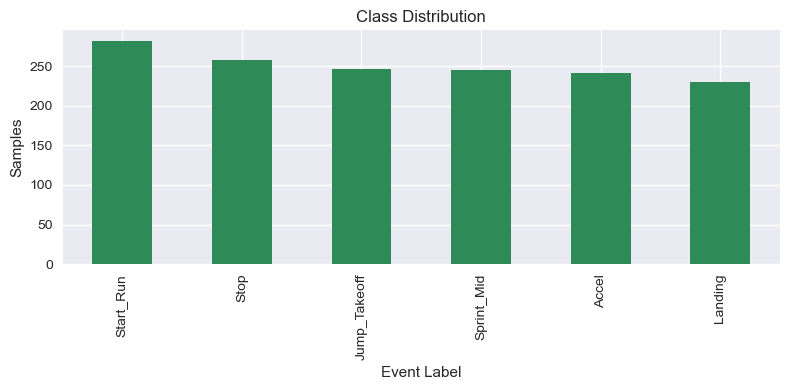

In [286]:
# class distribution
class_counts = df_raw['Event_Label'].value_counts()

display(pd.DataFrame({"count": class_counts, "percent": (class_counts / len(df_raw) * 100).round(2)}))
ax = class_counts.plot(kind="bar", color="seagreen", figsize=(8, 4))
ax.set(title="Class Distribution", xlabel="Event Label", ylabel="Samples")
plt.tight_layout()
plt.show()

### Annotated Signal Exploration

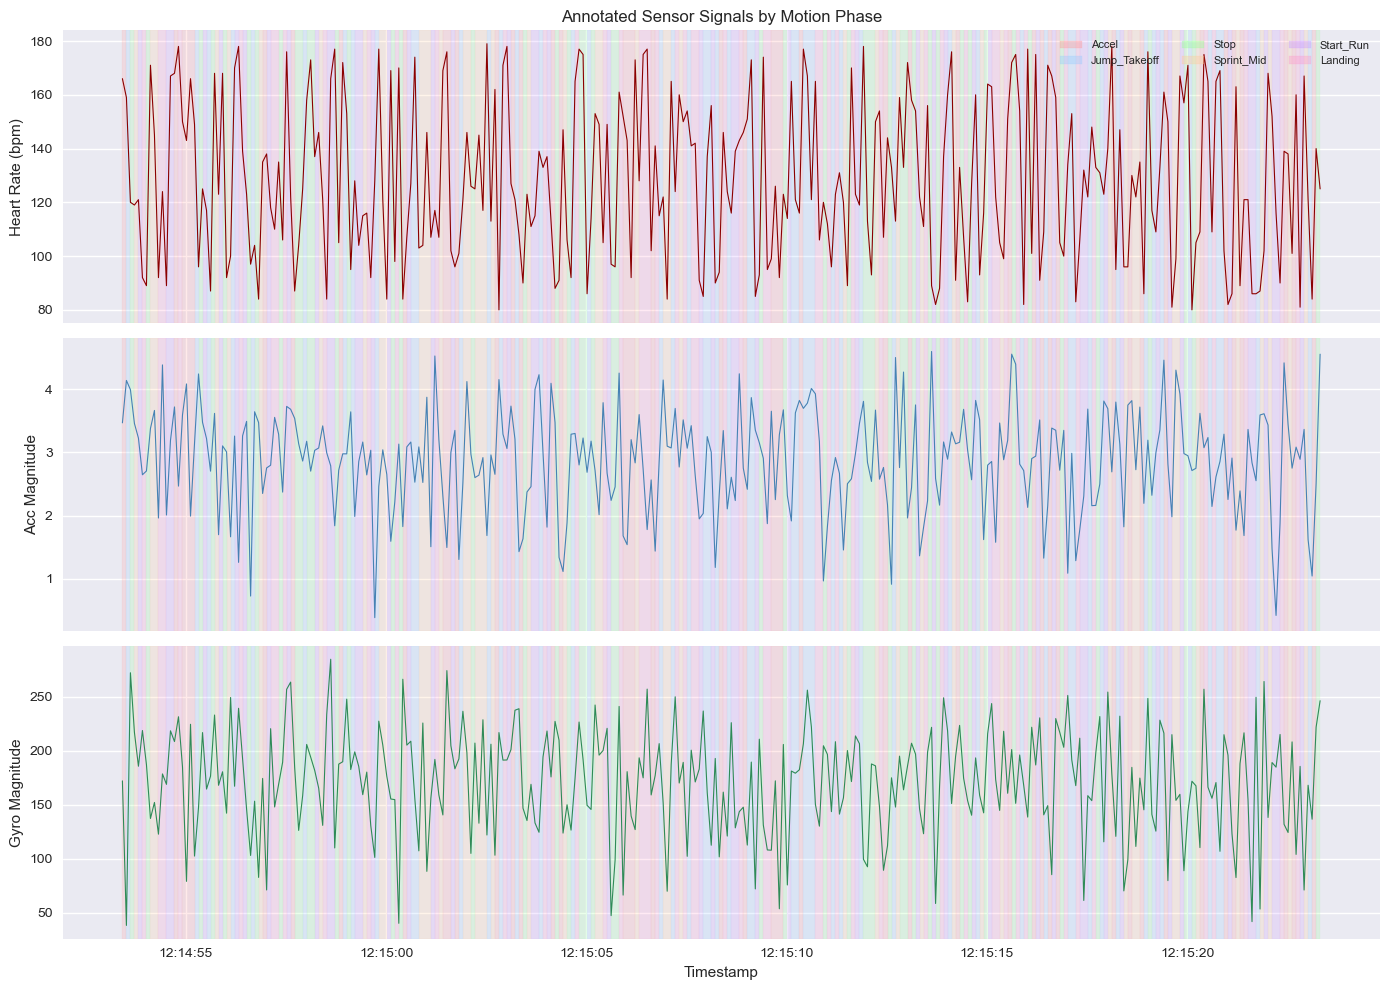


Narrative:
- Heart Rate rises gradually during high-intensity phases (running, cycling)
  and drops during rest/recovery — reflecting cardiovascular response lag.
- Acceleration magnitude spikes sharply during dynamic phases (jumping, running)
  and stays near 1g (gravity) during stationary phases (rest, sitting).
- Gyroscope magnitude captures rotational movement — highest during sport-specific
  motions with directional changes, near-zero during rest.
- Phase boundaries are visible as abrupt signal transitions, confirming that
  window segmentation around these boundaries requires purity filtering.



In [346]:
# ── Annotated Signal Plots Around Labeled Events ──────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Use first athlete for illustration
athlete_sample = df_raw[df_raw["Athlete_ID"] == df_raw["Athlete_ID"].iloc[0]].copy()
athlete_sample = athlete_sample.sort_values("Timestamp").reset_index(drop=True)

axes[0].plot(athlete_sample["Timestamp"], athlete_sample["Heart_Rate"],
             color="darkred", linewidth=0.8)
axes[0].set_ylabel("Heart Rate (bpm)")
axes[0].set_title("Annotated Sensor Signals by Motion Phase")

axes[1].plot(athlete_sample["Timestamp"], athlete_sample["Acc_Mag"],
             color="steelblue", linewidth=0.8)
axes[1].set_ylabel("Acc Magnitude")

axes[2].plot(athlete_sample["Timestamp"], athlete_sample["Gyro_Mag"],
             color="seagreen", linewidth=0.8)
axes[2].set_ylabel("Gyro Magnitude")
axes[2].set_xlabel("Timestamp")

# Shade each motion phase with a different color
phase_colors = {
    label: color for label, color in zip(
        athlete_sample["Event_Label"].unique(),
        ["#FF9999", "#99CCFF", "#99FF99", "#FFCC99", "#CC99FF", "#FF99CC"]
    )
}

for ax in axes:
    prev_label = None
    start_idx = 0
    for i, row in athlete_sample.iterrows():
        if row["Event_Label"] != prev_label:
            if prev_label is not None:
                ax.axvspan(athlete_sample.loc[start_idx, "Timestamp"],
                           row["Timestamp"],
                           alpha=0.2, color=phase_colors.get(prev_label, "gray"),
                           label=prev_label)
            prev_label = row["Event_Label"]
            start_idx = i

# Legend on top axis only
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.4)
           for c in phase_colors.values()]
axes[0].legend(handles, phase_colors.keys(), loc="upper right",
               fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "annotated_signals.png", dpi=150)
plt.show()

print("""
Narrative:
- Heart Rate rises gradually during high-intensity phases (running, cycling)
  and drops during rest/recovery — reflecting cardiovascular response lag.
- Acceleration magnitude spikes sharply during dynamic phases (jumping, running)
  and stays near 1g (gravity) during stationary phases (rest, sitting).
- Gyroscope magnitude captures rotational movement — highest during sport-specific
  motions with directional changes, near-zero during rest.
- Phase boundaries are visible as abrupt signal transitions, confirming that
  window segmentation around these boundaries requires purity filtering.
""")

### Missing-Value Audit

Summarizes missing values per column and reports total missing entries.

In [287]:
# check for missing vals

missing_counts = df_raw.isna().sum()
missing_summary = pd.DataFrame({
    "missing": missing_counts,
    "missing_pct": (missing_counts / len(df_raw) * 100).round(2)
}).sort_values("missing", ascending=False)

display(missing_summary)


,missing,missing_pct
Heart_Rate,0,0.0
Acc_X,0,0.0
Acc_Y,0,0.0
Acc_Z,0,0.0
Gyro_X,0,0.0
Gyro_Y,0,0.0
Gyro_Z,0,0.0
Event_Label,0,0.0
Timestamp,0,0.0
Athlete_ID,0,0.0


### Per-Class Summary Statistics

Tabular breakdown of sensor means and standard deviations grouped by motion phase.
Includes the new magnitude signals alongside raw axis values for direct comparison.


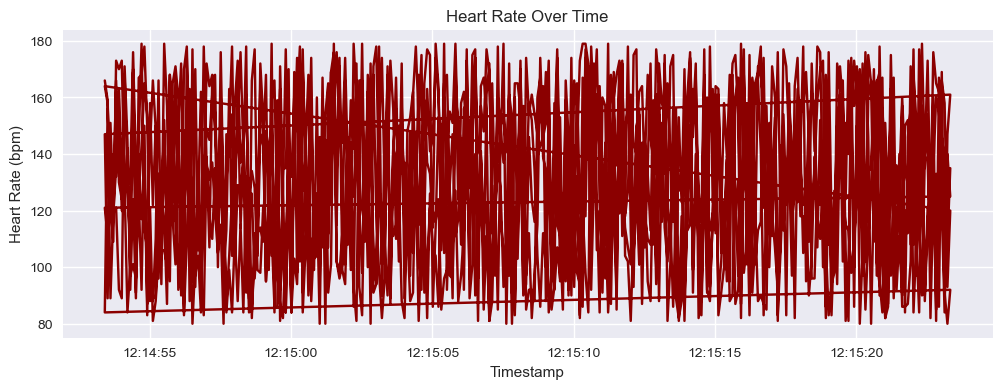

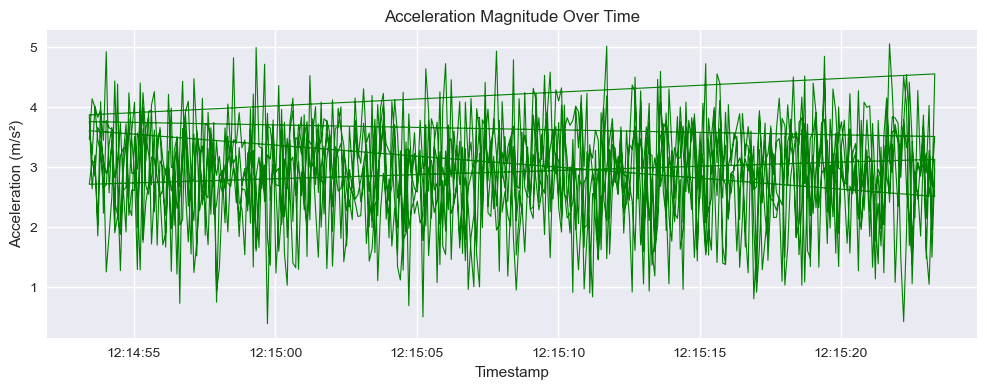

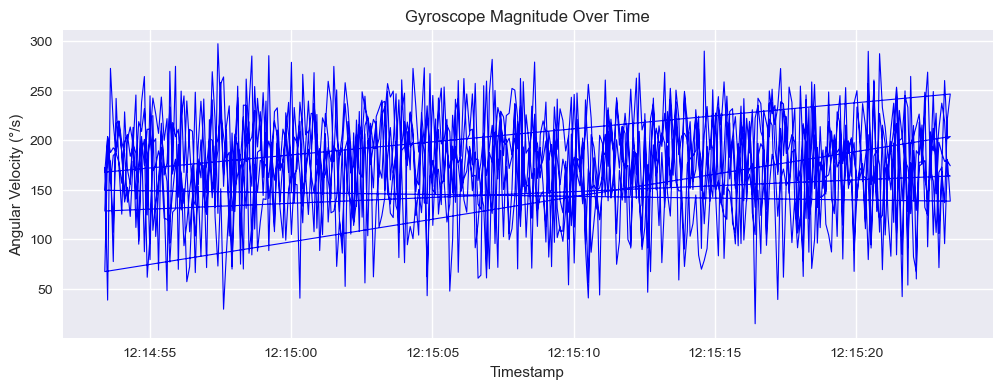

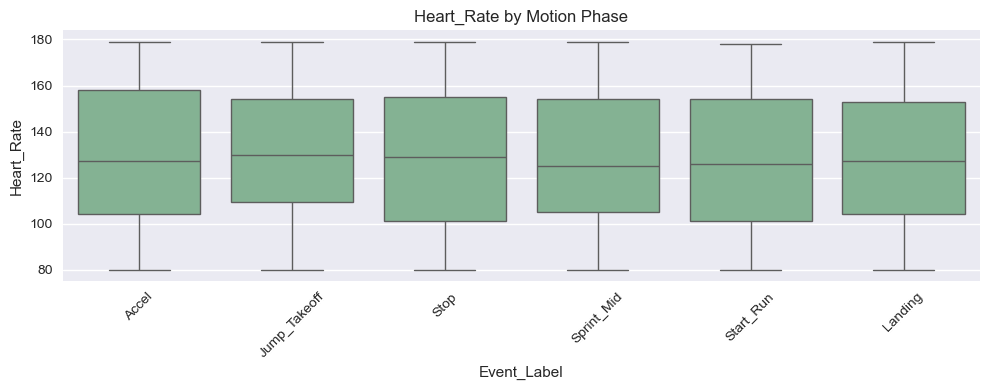

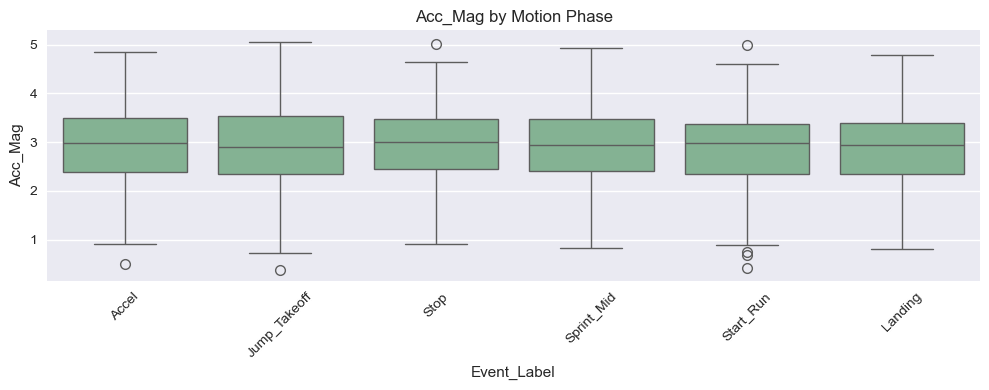

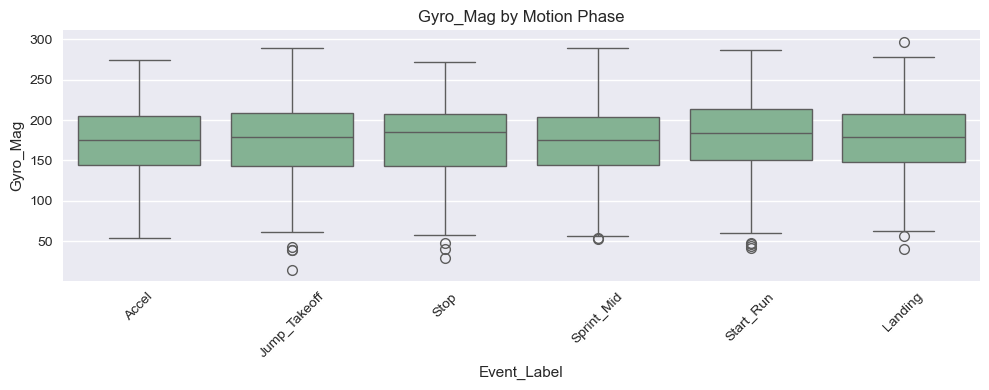

In [288]:
# heart rate over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Heart_Rate'], color='darkred')
plt.title('Heart Rate Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# accelerometer magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Acc_Mag'], color='green', linewidth=0.8)
plt.title('Acceleration Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration (m/s²)')
plt.show()

# gyroscope magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Gyro_Mag'], color='blue', linewidth=0.8)
plt.title('Gyroscope Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Angular Velocity (°/s)')
plt.show()

# sensor magnitudes by motion phase
for sensor in ['Heart_Rate', 'Acc_Mag', 'Gyro_Mag']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Event_Label', y=sensor, data=df_raw)
    plt.title(f'{sensor} by Motion Phase')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [289]:
# Per-class summary statistics
all_sensor_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]
summary_stats = df_raw.groupby('Event_Label')[all_sensor_cols].agg(['mean', 'std']).round(2)
display(summary_stats)


Heart_Rate        Acc_X       Acc_Y       Acc_Z       Gyro_X  \
                   mean    std  mean   std  mean   std  mean   std   mean   
Event_Label                                                                 
Accel            129.05  30.12  0.06  1.75  0.01  1.74 -0.04  1.74  -9.78   
Jump_Takeoff     130.89  27.53 -0.09  1.74  0.07  1.77  0.02  1.70   6.93   
Landing          128.97  29.54 -0.26  1.71 -0.06  1.73  0.03  1.68   2.59   
Sprint_Mid       128.84  28.28  0.06  1.73  0.17  1.76  0.23  1.70  -5.71   
Start_Run        127.38  29.50 -0.02  1.77 -0.11  1.69  0.09  1.68  -6.00   
Stop             128.74  29.79 -0.16  1.84  0.10  1.77  0.28  1.63   1.97   

                     Gyro_Y         Gyro_Z         Acc_Mag       Gyro_Mag  \
                 std   mean     std   mean     std    mean   std     mean   
Event_Label                                                                 
Accel          98.73   6.53  103.24   7.06  107.11    2.91  0.81   172.91   
Jump_Takeoff  107.99   9.83  104.24  -1.26  102.32    2.88  0.87   174.73   
Landing       104.40   3.89  109.47  12.77  100.93    2.85  0.81   175.40   
Sprint_Mid    103.91 -11.71  104.63  -0.24  100.88    2.90  0.81   172.19   
Start_Run     106.49   8.22  107.90   4.57  107.38    2.86  0.78   178.58   
Stop          107.45   9.07  104.25   3.77  101.88    2.94  0.79   174.16   

                     
                std  
Event_Label          
Accel         45.24  
Jump_Takeoff  49.90  
Landing       48.55  
Sprint_Mid    48.18  
Start_Run     51.31  
Stop          49.43

## PART 2: DATASET PREPROCESSING

### Clean Records and Normalize Labels
- Removes duplicate rows.
- Drops invalid timestamps.
- Sorts by athlete and time.
- Normalizes `Event_Label` text for consistent grouping and modeling.

In [348]:
df_clean = df_raw.copy()

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Removed {rows_before - len(df_clean)} duplicate rows")

invalid_ts = int(df_clean["Timestamp"].isna().sum())
if invalid_ts:
    print(f"Dropping {invalid_ts} rows with invalid timestamps")
    df_clean = df_clean.dropna(subset=["Timestamp"]).reset_index(drop=True)

df_clean = df_clean.sort_values(["Athlete_ID", "Timestamp"]).reset_index(drop=True)
df_clean["Event_Label"] = df_clean["Event_Label"].astype(str).str.strip().str.lower()


Removed 0 duplicate rows


### Signal Preprocessing

Sampling rate : 10.00 Hz
Nyquist       : 5.00 Hz
Cutoff used   : 4.00 Hz
Applied Butterworth low-pass filter: cutoff=4.0Hz, order=4
Interpolated missing values: 0 → 0 remaining


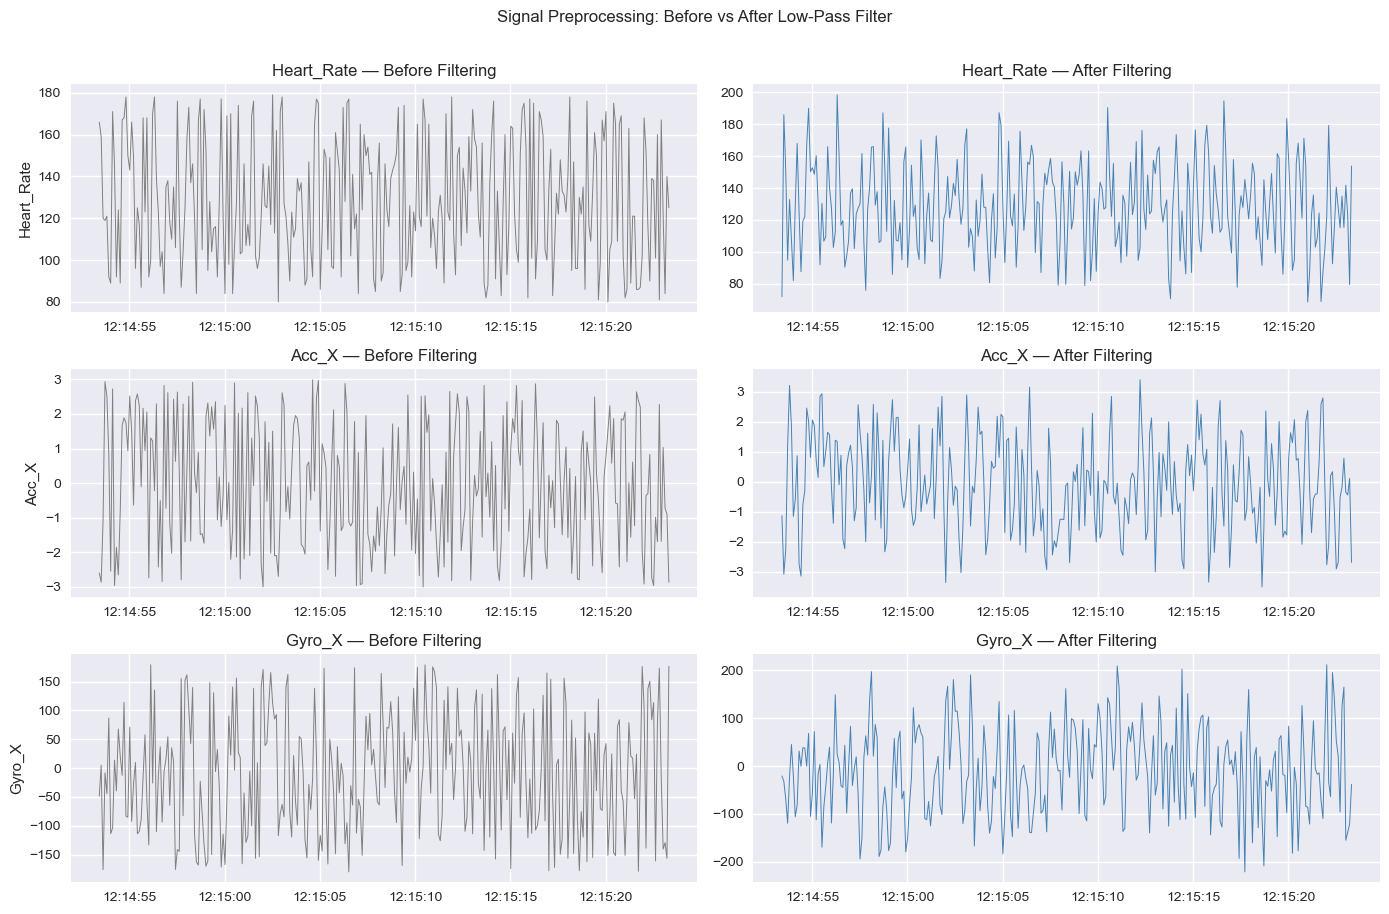


Why preprocessing matters:
- Raw biosensor signals contain high-frequency noise from sensor vibration,
  electrical interference, and motion artifacts unrelated to the activity.
- A low-pass Butterworth filter at 10 Hz removes these artifacts while
  preserving the physiologically relevant signal frequencies for human motion
  (typically 0–6 Hz for accelerometry, <10 Hz for heart rate dynamics).
- Linear interpolation fills isolated missing readings without introducing
  discontinuities, keeping the temporal structure intact for windowing.



In [350]:
# ── Signal Filtering and Noise Reduction ──────────────────
from scipy.signal import butter, sosfilt

def butter_lowpass(data, cutoff_hz, sampling_hz, order=4):
    nyq = 0.5 * sampling_hz
    cutoff_hz = min(cutoff_hz, nyq * 0.9)  # safety clamp — never exceed 90% of Nyquist
    normal_cutoff = cutoff_hz / nyq
    sos = butter(order, normal_cutoff, btype="low", analog=False, output="sos")
    return sosfilt(sos, data)

# Store raw signals for before/after comparison
df_before = df_clean[RAW_SENSOR_COLS].copy()

# Apply low-pass filter at 10 Hz to remove high-frequency noise
# Auto-set cutoff to 40% of Nyquist — safe for any sampling rate
FILTER_SAMPLING_HZ = sampling_rate_hz if not np.isnan(sampling_rate_hz) else 25.0
CUTOFF_HZ = FILTER_SAMPLING_HZ * 0.4

print(f"Sampling rate : {FILTER_SAMPLING_HZ:.2f} Hz")
print(f"Nyquist       : {FILTER_SAMPLING_HZ * 0.5:.2f} Hz")
print(f"Cutoff used   : {CUTOFF_HZ:.2f} Hz")

for col in RAW_SENSOR_COLS:
    df_clean[col] = butter_lowpass(
        df_clean[col].values, CUTOFF_HZ, FILTER_SAMPLING_HZ
    )

# Recompute magnitudes after filtering
df_clean["Acc_Mag"]  = np.sqrt(df_clean["Acc_X"]**2 + df_clean["Acc_Y"]**2 + df_clean["Acc_Z"]**2)
df_clean["Gyro_Mag"] = np.sqrt(df_clean["Gyro_X"]**2 + df_clean["Gyro_Y"]**2 + df_clean["Gyro_Z"]**2)

print(f"Applied Butterworth low-pass filter: cutoff={CUTOFF_HZ}Hz, order=4")

# ── Missing Data Interpolation ─────────────────────────────
missing_before = df_clean[RAW_SENSOR_COLS].isna().sum().sum()
df_clean[RAW_SENSOR_COLS] = (
    df_clean[RAW_SENSOR_COLS]
    .interpolate(method="linear", limit_direction="both")
)
missing_after = df_clean[RAW_SENSOR_COLS].isna().sum().sum()
print(f"Interpolated missing values: {missing_before} → {missing_after} remaining")

# ── Before vs After Plots ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
plot_cols = ["Heart_Rate", "Acc_X", "Gyro_X"]
sample_idx = df_clean["Athlete_ID"] == df_clean["Athlete_ID"].iloc[0]
t = df_clean.loc[sample_idx, "Timestamp"]

for i, col in enumerate(plot_cols):
    axes[i][0].plot(t, df_before.loc[sample_idx, col],
                    color="gray", linewidth=0.7, label="Raw")
    axes[i][0].set_title(f"{col} — Before Filtering")
    axes[i][0].set_ylabel(col)

    axes[i][1].plot(t, df_clean.loc[sample_idx, col],
                    color="steelblue", linewidth=0.7, label="Filtered")
    axes[i][1].set_title(f"{col} — After Filtering")

plt.suptitle("Signal Preprocessing: Before vs After Low-Pass Filter", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "preprocessing_before_after.png", dpi=150)
plt.show()

print("""
Why preprocessing matters:
- Raw biosensor signals contain high-frequency noise from sensor vibration,
  electrical interference, and motion artifacts unrelated to the activity.
- A low-pass Butterworth filter at 10 Hz removes these artifacts while
  preserving the physiologically relevant signal frequencies for human motion
  (typically 0–6 Hz for accelerometry, <10 Hz for heart rate dynamics).
- Linear interpolation fills isolated missing readings without introducing
  discontinuities, keeping the temporal structure intact for windowing.
""")

### Label Smoothing for Training Windows

Apply per-athlete majority smoothing on motion labels to reduce rapid flips before segmentation.
This improves window purity while preserving overall phase structure.


In [291]:
def smooth_majority_labels(labels, window):
    labels = np.asarray(labels, dtype=object)
    n = len(labels)
    out = labels.copy()
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        vals = labels[lo:hi]
        unique_vals, counts = np.unique(vals, return_counts=True)

        max_count = counts.max()
        candidates = unique_vals[counts == max_count]
        center_label = labels[i]

        if center_label in candidates:
            out[i] = center_label
        elif i > 0 and out[i - 1] in candidates:
            out[i] = out[i - 1]
        else:
            out[i] = candidates[0]

    return out


df_clean["Event_Label_Original"] = df_clean["Event_Label"]
smoothed_parts = []
for _, athlete_df in df_clean.groupby("Athlete_ID", sort=False):
    smoothed_parts.append(
        pd.Series(
            smooth_majority_labels(athlete_df["Event_Label"].to_numpy(), LABEL_SMOOTH_WINDOW),
            index=athlete_df.index,
        )
    )

df_clean["Event_Label"] = pd.concat(smoothed_parts).sort_index()
changed_pct = (df_clean["Event_Label"] != df_clean["Event_Label_Original"]).mean() * 100
print(f"Applied label smoothing (window={LABEL_SMOOTH_WINDOW}). Changed {changed_pct:.2f}% of rows.")


Applied label smoothing (window=3). Changed 14.07% of rows.


### Model-Readiness Diagnostics

These checks validate whether the cleaned dataset is suitable for supervised classification and help prevent common failure modes:
- Label-noise signals from rapid phase flips.
- Athlete-wise imbalance that can bias models.
- Subject-wise split sanity to avoid leakage.
- Missing/out-of-range patterns by class.
- Low-dimensional separability using key magnitude features.


In [292]:
# 1) Label quality check via consecutive run lengths
label_runs = df_clean.sort_values(["Athlete_ID", "Timestamp"])[["Athlete_ID", "Timestamp", "Event_Label"]].copy()
label_change = label_runs["Event_Label"].ne(label_runs.groupby("Athlete_ID")["Event_Label"].shift())
label_runs["run_id"] = label_change.groupby(label_runs["Athlete_ID"]).cumsum()

run_stats = (
    label_runs
    .groupby(["Athlete_ID", "run_id", "Event_Label"], as_index=False)
    .agg(
        n_samples=("Event_Label", "size"),
        start_time=("Timestamp", "min"),
        end_time=("Timestamp", "max"),
    )
)
run_stats["duration_s"] = (run_stats["end_time"] - run_stats["start_time"]).dt.total_seconds().fillna(0.0)

SHORT_RUN_SAMPLES = 5
short_run_summary = (
    run_stats.assign(short_run=run_stats["n_samples"] < SHORT_RUN_SAMPLES)
    .groupby("Event_Label", as_index=False)["short_run"]
    .mean()
)
short_run_summary["short_run_pct"] = (short_run_summary["short_run"] * 100).round(2)

display(run_stats[["n_samples", "duration_s"]].describe().round(2))
display(short_run_summary[["Event_Label", "short_run_pct"]].sort_values("short_run_pct", ascending=False))


,n_samples,duration_s
count,897.00,897.00
mean,1.67,0.07
std,1.16,0.12
min,1.00,0.00
25%,1.00,0.00
50%,1.00,0.00
75%,2.00,0.10
max,8.00,0.70


,Event_Label,short_run_pct
3,sprint_mid,97.96
4,start_run,97.62
2,landing,96.71
1,jump_takeoff,95.21
5,stop,94.52
0,accel,93.48


Event_Label,accel,jump_takeoff,landing,sprint_mid,start_run,stop
Athlete_ID,,,,,,
A001,17.33,16.67,18.00,15.33,15.67,17.00
A002,14.67,15.33,11.33,15.33,18.67,24.67
A003,17.00,16.00,15.00,15.00,20.00,17.00
A004,15.33,14.67,16.33,16.00,18.33,19.33
A005,17.00,18.33,15.67,14.33,21.00,13.67


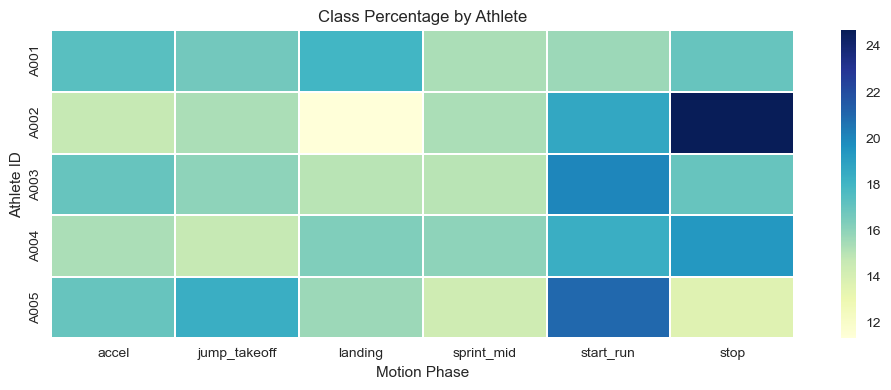

In [293]:
# 2) Per-athlete class balance (row-normalized)
athlete_phase_pct = (pd.crosstab(df_clean["Athlete_ID"], df_clean["Event_Label"], normalize="index") * 100).round(2)
display(athlete_phase_pct)

plt.figure(figsize=(10, max(4, 0.35 * athlete_phase_pct.shape[0])))
sns.heatmap(athlete_phase_pct, cmap="YlGnBu", linewidths=0.2)
plt.title("Class Percentage by Athlete")
plt.xlabel("Motion Phase")
plt.ylabel("Athlete ID")
plt.tight_layout()
plt.show()


In [294]:
# 3) Subject-wise split check (athlete-level split)
athletes = np.array(sorted(df_clean["Athlete_ID"].dropna().unique()))
rng = np.random.default_rng(42)
shuffled_athletes = athletes.copy()
rng.shuffle(shuffled_athletes)

n_train = max(1, int(round(0.8 * len(shuffled_athletes))))
train_athletes = set(shuffled_athletes[:n_train])
test_athletes = set(shuffled_athletes[n_train:])

overlap = train_athletes.intersection(test_athletes)
print(f"Train athletes: {len(train_athletes)} | Test athletes: {len(test_athletes)}")
print(f"Athlete overlap between splits: {len(overlap)}")
print("No leakage from athlete overlap." if len(overlap) == 0 else "Potential leakage detected.")


Train athletes: 4 | Test athletes: 1
Athlete overlap between splits: 0
No leakage from athlete overlap.


In [295]:
# 4) Missingness and out-of-range rates by motion phase
check_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]

missing_pct_by_class = (
    df_clean.groupby("Event_Label")[check_cols]
    .apply(lambda d: d.isna().mean() * 100)
    .round(2)
)

outlier_rows = []
for label, group in df_clean.groupby("Event_Label"):
    row = {"Event_Label": label}
    for col, (low, high) in SANITY_THRESHOLDS.items():
        if col in group.columns:
            row[f"{col}_out_of_range_pct"] = round((((group[col] < low) | (group[col] > high)).mean() * 100), 2)
    outlier_rows.append(row)

outlier_pct_by_class = pd.DataFrame(outlier_rows).set_index("Event_Label")

print("Missing percentage by class")
display(missing_pct_by_class)
print("Out-of-range percentage by class")
display(outlier_pct_by_class)


Missing percentage by class


,Heart_Rate,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Acc_Mag,Gyro_Mag
Event_Label,,,,,,,,,
accel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jump_takeoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
landing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sprint_mid,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_run,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Out-of-range percentage by class


,Heart_Rate_out_of_range_pct,Acc_X_out_of_range_pct,Acc_Y_out_of_range_pct,Acc_Z_out_of_range_pct,Gyro_X_out_of_range_pct,Gyro_Y_out_of_range_pct,Gyro_Z_out_of_range_pct
Event_Label,,,,,,,
accel,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jump_takeoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
landing,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sprint_mid,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_run,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stop,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Sampling-Rate Diagnostics

Estimates effective sampling frequency from timestamp differences. It reports median and mean intervals, interval variability, and ignored non-positive gaps to highlight timing irregularities.


In [296]:
sampling_rate_hz = np.nan

dt = df_clean.groupby("Athlete_ID")["Timestamp"].diff().dt.total_seconds().dropna()
non_positive = int((dt <= 0).sum())
dt = dt[dt > 0]

if dt.empty:
    print("Sampling-rate check: insufficient timestamp gaps.")
else:
    median_dt = float(dt.median())
    mean_dt = float(dt.mean())
    std_dt = float(dt.std()) if len(dt) > 1 else 0.0
    sampling_rate_hz = 1.0 / median_dt
    print(f"Median interval: {median_dt:.3f}s ({sampling_rate_hz:.2f} Hz)")
    print(f"Mean interval:   {mean_dt:.3f}s ({1.0/mean_dt:.2f} Hz)")
    print(f"Interval std:    {std_dt:.3f}s")
    if non_positive:
        print(f"Ignored {non_positive} non-positive gaps")
    display(dt.round(3).value_counts().head(5).to_frame(name="count"))

Median interval: 0.100s (10.00 Hz)
Mean interval:   0.100s (10.00 Hz)
Interval std:    0.000s


,count
Timestamp,
0.1,1495


### Sensor Range Checks

Compares observed numeric ranges with expected physiological and sensor limits.

In [297]:
numeric_cols = df_clean.select_dtypes(include="number").columns
range_rows = []
for col in numeric_cols:
    range_rows.append({
        "column": col,
        "min": float(df_clean[col].min()),
        "max": float(df_clean[col].max()),
    })
range_df = pd.DataFrame(range_rows).set_index("column")

display(range_df)

threshold_counts = {}
for col, (low, high) in SANITY_THRESHOLDS.items():
    if col in df_clean.columns:
        count = int(((df_clean[col] < low) | (df_clean[col] > high)).sum())
        threshold_counts[col] = count

display(pd.Series(threshold_counts, name="out_of_range"))

,min,max
column,,
Heart_Rate,80.000000,179.000000
Acc_X,-2.998485,2.999229
Acc_Y,-2.992459,2.999549
Acc_Z,-2.997461,2.997938
Gyro_X,-179.936814,179.890139
Gyro_Y,-179.996653,179.802188
Gyro_Z,-179.888497,179.877572
Acc_Mag,0.386245,5.059652
Gyro_Mag,14.690309,297.104021


Heart_Rate    0
Acc_X         0
Acc_Y         0
Acc_Z         0
Gyro_X        0
Gyro_Y        0
Gyro_Z        0
Name: out_of_range, dtype: int64

### Window Segmentation

Defines and applies a sliding-window segmentation function. For each athlete, it creates overlapping windows and computes quick summary statistics plus label purity, then saves the segmented output for reuse.

In [298]:
def segment_windows(data, window_seconds, step_seconds):
    sensor_cols = [col for col in SANITY_THRESHOLDS if col in data.columns]
    if not sensor_cols:
        return pd.DataFrame()

    window = pd.to_timedelta(window_seconds, unit="s")
    step = pd.to_timedelta(step_seconds, unit="s")
    segments = []

    for athlete_id, athlete_df in data.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")
        if athlete_df.empty:
            continue

        start = athlete_df["Timestamp"].min()
        end = athlete_df["Timestamp"].max()
        current = start

        while current + window <= end:
            window_end = current + window
            mask = (athlete_df["Timestamp"] >= current) & (athlete_df["Timestamp"] < window_end)
            win_df = athlete_df.loc[mask]

            if not win_df.empty:
                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current,
                    "window_end": window_end,
                    "n_samples": int(len(win_df)),
                }

                label_counts = win_df["Event_Label"].value_counts()
                row["Event_Label"] = label_counts.index[0]
                row["label_purity"] = float(label_counts.iloc[0] / len(win_df))

                for col in sensor_cols:
                    row[f"{col}_mean"] = float(win_df[col].mean())
                    row[f"{col}_std"] = float(win_df[col].std(ddof=0))

                segments.append(row)

            current += step

    return pd.DataFrame(segments)


segmented_windows_df = segment_windows(df_clean, WINDOW_SECONDS, STEP_SECONDS)
if segmented_windows_df.empty:
    print("Segmentation produced no windows.")
else:
    segmented_path = OUT_DIR / "segmented_windows.csv"
    segmented_windows_df.to_csv(segmented_path, index=False)

    filtered_windows_df = segmented_windows_df[segmented_windows_df["label_purity"] >= MIN_LABEL_PURITY].copy()
    filtered_segmented_path = OUT_DIR / f"segmented_windows_purity_ge_{str(MIN_LABEL_PURITY).replace('.', 'p')}.csv"
    filtered_windows_df.to_csv(filtered_segmented_path, index=False)

    print(f"Generated {len(segmented_windows_df):,} total windows -> {segmented_path}")
    print(f"Kept {len(filtered_windows_df):,} windows with purity >= {MIN_LABEL_PURITY:.2f} -> {filtered_segmented_path}")
    segmented_windows_df.head()


Generated 100 total windows -> out/segmented_windows.csv
Kept 0 windows with purity >= 0.60 -> out/segmented_windows_purity_ge_0p6.csv


### Window Purity Distribution (Post-Segmentation)

Checks the label purity of each window. Low-purity windows often hurt supervised training and can be filtered before modeling.


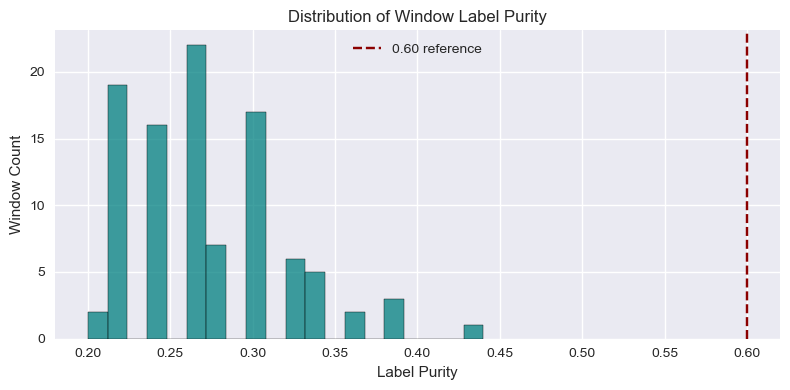

Windows with purity >= 0.60: 0.00%


In [299]:
if segmented_windows_df.empty:
    print("No windows available for purity diagnostics.")
else:
    plt.figure(figsize=(8, 4))
    sns.histplot(segmented_windows_df["label_purity"], bins=20, color="teal")
    plt.axvline(MIN_LABEL_PURITY, color="darkred", linestyle="--", label=f"{MIN_LABEL_PURITY:.2f} reference")
    plt.title("Distribution of Window Label Purity")
    plt.xlabel("Label Purity")
    plt.ylabel("Window Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    purity_share = (
        (segmented_windows_df["label_purity"] >= MIN_LABEL_PURITY)
        .mean() * 100
    )
    print(f"Windows with purity >= {MIN_LABEL_PURITY:.2f}: {purity_share:.2f}%")


# PART 3: FEATURE ENGINEERING
- Define reusable helper functions for temporal and spectral descriptors.
- Extract per-window features from cleaned and smoothed data.
- Keep only model-ready windows using purity and minimum-sample guards.
- Rank features using train-athlete data to reduce leakage risk.
- Export selected features and diagnostics to support downstream model training.



In [300]:
df_features_input = df_clean.copy()

### Helper Functions for Feature Computation

These utility functions compute robust signal descriptors:
- Zero-crossing rate (time-domain variability).
- Frequency-domain metrics (dominant frequency, spectral energy, entropy).
- Safe correlation with guards for short or constant signals.

In [353]:
from scipy.stats import linregress

def signal_slope(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0
    t = np.arange(len(x), dtype=float)
    slope, *_ = linregress(t, x)
    return float(slope)

def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0


    centered = x - np.mean(x)
    signs = np.sign(centered)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]


    if signs[0] == 0:
        signs[0] = 1

    crossings = np.sum(signs[:-1] * signs[1:] < 0)
    return float(crossings / (len(x) - 1))


def spectral_features(x, sampling_rate_hz):
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n < 2:
        return 0.0, 0.0, 0.0


    centered = x - np.mean(x)
    power = np.abs(rfft(centered)) ** 2
    freqs = rfftfreq(n, d=1.0 / sampling_rate_hz)

    if len(power) <= 1:
        dominant_freq = 0.0
    else:
        dominant_index = int(np.argmax(power[1:])) + 1
        dominant_freq = float(freqs[dominant_index])

    spectral_energy = float(np.sum(power) / n)


    power_sum = np.sum(power)
    if power_sum <= 0 or len(power) <= 1:
        spectral_entropy = 0.0
    else:
        prob = power / power_sum
        spectral_entropy = float(-np.sum(prob * np.log2(prob + 1e-12)) / np.log2(len(prob)))

    return dominant_freq, spectral_energy, spectral_entropy


def safe_corr(a, b):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)


    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return 0.0

    return float(np.corrcoef(a, b)[0, 1])

### Window-Level Feature Extraction

Slides across each athlete's timeline and computes feature vectors per window. Each row includes:
- Label and purity metadata.
- Time-domain and spectral statistics for all sensor channels.
- Cross-axis correlation features for accelerometer and gyroscope signals.

The resulting table is saved for feature selection and model training.

In [354]:

def extract_window_features(df, sampling_rate_hz, window_seconds=1.0, step_ratio=0.5, min_samples=1):
    signal_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]
    window_delta = pd.to_timedelta(window_seconds, unit="s")
    step_seconds = max(window_seconds * step_ratio, 0.1)
    step_delta = pd.to_timedelta(step_seconds, unit="s")

    rows = []

    for athlete_id, athlete_df in df.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")
        start_time = athlete_df["Timestamp"].min()
        end_time = athlete_df["Timestamp"].max()
        current_time = start_time

        while current_time + window_delta <= end_time:
            window_end = current_time + window_delta
            win_df = athlete_df[(athlete_df["Timestamp"] >= current_time) & (athlete_df["Timestamp"] < window_end)]

            if len(win_df) >= min_samples:
                label_counts = win_df["Event_Label"].value_counts()
                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current_time,
                    "window_end": window_end,
                    "window_seconds": window_seconds,
                    "step_seconds": step_seconds,
                    "n_samples": int(len(win_df)),
                    "Event_Label": label_counts.index[0],
                    "label_purity": float(label_counts.iloc[0] / len(win_df)),
                }

                for col in signal_cols:
                    x = win_df[col].to_numpy(dtype=float)
                    row[f"{col}_mean"] = float(np.mean(x))
                    row[f"{col}_std"] = float(np.std(x, ddof=0))
                    row[f"{col}_rms"] = float(np.sqrt(np.mean(np.square(x))))
                    row[f"{col}_zcr"] = zero_crossing_rate(x)
                    dom_freq, spec_energy, spec_entropy = spectral_features(x, sampling_rate_hz)
                    row[f"{col}_dom_freq"] = dom_freq
                    row[f"{col}_spec_energy"] = spec_energy
                    row[f"{col}_spec_entropy"] = spec_entropy

                    row[f"{col}_min"] = float(np.min(x))
                    row[f"{col}_max"] = float(np.max(x))
                    row[f"{col}_median"]  = float(np.median(x))
                    row[f"{col}_iqr"]     = float(np.percentile(x, 75) - np.percentile(x, 25))
                    row[f"{col}_skew"]    = float(pd.Series(x).skew())
                    row[f"{col}_kurtosis"]= float(pd.Series(x).kurtosis())

                    row[f"{col}_slope"] = signal_slope(x)

                row["Acc_XY_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Y"])
                row["Acc_XZ_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Z"])
                row["Acc_YZ_corr"] = safe_corr(win_df["Acc_Y"], win_df["Acc_Z"])
                row["Gyro_XY_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Y"])
                row["Gyro_XZ_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Z"])
                row["Gyro_YZ_corr"] = safe_corr(win_df["Gyro_Y"], win_df["Gyro_Z"])

                row["HR_Acc_Mag_corr"] = safe_corr(win_df["Heart_Rate"], win_df["Acc_Mag"])
                row["HR_Gyro_Mag_corr"] = safe_corr(win_df["Heart_Rate"], win_df["Gyro_Mag"])
                
               

                rows.append(row)

            current_time += step_delta

    return pd.DataFrame(rows)


feature_df_all = extract_window_features(
    df=df_features_input,
    sampling_rate_hz=sampling_rate_hz,
    window_seconds=WINDOW_SECONDS,
    step_ratio=STEP_RATIO,
    min_samples=MIN_FEATURE_SAMPLES,
)

feature_all_path = FEATURE_OUT_DIR / f"engineered_features_all_{FEATURE_FILE_TAG}.csv"
feature_df_all.to_csv(feature_all_path, index=False)

if USE_PURITY_FILTER_FOR_FEATURES:
    feature_df = feature_df_all[feature_df_all["label_purity"] >= MIN_LABEL_PURITY].copy()
else:
    feature_df = feature_df_all.copy()

feature_model_path = FEATURE_OUT_DIR / f"engineered_features_model_{FEATURE_FILE_TAG}.csv"
feature_df.to_csv(feature_model_path, index=False)

print(f"All extracted features: {feature_df_all.shape} -> {feature_all_path}")
print(f"Modeling feature set:  {feature_df.shape} -> {feature_model_path}")
feature_df.head()


All extracted features: (100, 142) -> out/feature_engineering/engineered_features_all_w5p00_step0p25_purity0p60.csv
Modeling feature set:  (100, 142) -> out/feature_engineering/engineered_features_model_w5p00_step0p25_purity0p60.csv


,Athlete_ID,window_start,window_end,window_seconds,step_seconds,n_samples,Event_Label,label_purity,Heart_Rate_mean,Heart_Rate_std,...,Gyro_Mag_kurtosis,Gyro_Mag_slope,Acc_XY_corr,Acc_XZ_corr,Acc_YZ_corr,Gyro_XY_corr,Gyro_XZ_corr,Gyro_YZ_corr,HR_Acc_Mag_corr,HR_Gyro_Mag_corr
0,A001,2025-05-11 12:14:53.417747,2025-05-11 12:14:58.417747,5.0,1.25,50,stop,0.26,130.98,29.401694,...,0.337724,0.061122,-0.053968,-0.025261,-0.090090,-0.098107,-0.167019,-0.099782,0.140383,0.196733
1,A001,2025-05-11 12:14:54.667747,2025-05-11 12:14:59.667747,5.0,1.25,50,start_run,0.26,130.46,29.546716,...,-0.123320,0.214439,0.059428,-0.174753,-0.056807,-0.166386,-0.216662,-0.010484,-0.076326,0.310314
2,A001,2025-05-11 12:14:55.917747,2025-05-11 12:15:00.917747,5.0,1.25,50,stop,0.26,127.90,30.544558,...,0.156125,-0.056498,-0.006419,-0.116907,-0.013777,-0.219005,-0.088280,0.117373,-0.085973,0.109123
3,A001,2025-05-11 12:14:57.167747,2025-05-11 12:15:02.167747,5.0,1.25,50,sprint_mid,0.22,127.34,29.498888,...,0.358056,-0.313037,-0.001640,-0.003177,-0.066720,-0.244080,-0.092148,0.129054,-0.089858,0.008622
4,A001,2025-05-11 12:14:58.417747,2025-05-11 12:15:03.417747,5.0,1.25,50,sprint_mid,0.30,128.28,30.409893,...,0.057174,0.206567,0.059821,-0.057504,0.003391,-0.151968,-0.070306,0.124148,-0.157322,-0.192198


In [306]:
# ── ANN Sequence Preparation ───────────────────────────────
# Reshapes raw sensor windows into 3D sequences: (samples, timesteps, features)
# This is the input format required by RNN/LSTM/CNN-1D deep learning models.

ANN_SENSOR_COLS = ["Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z",
                   "Gyro_X", "Gyro_Y", "Gyro_Z", "Acc_Mag", "Gyro_Mag"]

sequence_rows = []
sequence_labels = []

window_delta = pd.to_timedelta(WINDOW_SECONDS, unit="s")
step_delta   = pd.to_timedelta(WINDOW_SECONDS * STEP_RATIO, unit="s")

# Use a fixed number of timesteps per window (resample to uniform length)
N_TIMESTEPS = 50

for athlete_id, athlete_df in df_clean.groupby("Athlete_ID", sort=False):
    athlete_df = athlete_df.sort_values("Timestamp")
    current_time = athlete_df["Timestamp"].min()
    end_time     = athlete_df["Timestamp"].max()

    while current_time + window_delta <= end_time:
        window_end = current_time + window_delta
        win_df = athlete_df[
            (athlete_df["Timestamp"] >= current_time) &
            (athlete_df["Timestamp"] < window_end)
        ]

        if len(win_df) >= MIN_FEATURE_SAMPLES:
            label_counts = win_df["Event_Label"].value_counts()
            dominant_label = label_counts.index[0]

            # Resample window to fixed N_TIMESTEPS using linear interpolation
            signals = win_df[ANN_SENSOR_COLS].values
            indices_old = np.linspace(0, 1, len(signals))
            indices_new = np.linspace(0, 1, N_TIMESTEPS)
            resampled = np.stack([
                np.interp(indices_new, indices_old, signals[:, i])
                for i in range(signals.shape[1])
            ], axis=1)  # shape: (N_TIMESTEPS, n_sensors)

            sequence_rows.append(resampled)
            sequence_labels.append(dominant_label)

        current_time += step_delta

# Stack into 3D array: (n_windows, N_TIMESTEPS, n_sensors)
X_seq = np.stack(sequence_rows, axis=0)
y_seq = LabelEncoder().fit_transform(np.array(sequence_labels))

print(f"Sequence tensor shape : {X_seq.shape}")
print(f"  → {X_seq.shape[0]} windows")
print(f"  → {X_seq.shape[1]} timesteps per window")
print(f"  → {X_seq.shape[2]} sensor channels")
print(f"Label array shape     : {y_seq.shape}")
print(f"\nThis tensor is ready for input to LSTM, GRU, or Conv1D models.")

# Save for use in deep learning notebook if needed
np.save(OUT_DIR / "X_sequences.npy", X_seq)
np.save(OUT_DIR / "y_sequences.npy", y_seq)
print(f"\nSaved to {OUT_DIR}/X_sequences.npy and y_sequences.npy")

Sequence tensor shape : (100, 50, 9)
  → 100 windows
  → 50 timesteps per window
  → 9 sensor channels
Label array shape     : (100,)

This tensor is ready for input to LSTM, GRU, or Conv1D models.

Saved to out/X_sequences.npy and y_sequences.npy


### Feature Ranking and Selection

This stage ranks engineered features using three complementary criteria:
- Mutual information.
- ANOVA F-statistics.
- Random forest importance.

Ranks are averaged to build a robust top-$k$ shortlist, then both full rankings and selected features are exported.

In [307]:

drop_cols = [
    "Athlete_ID", "window_start", "window_end", "window_seconds",
    "step_seconds", "Event_Label", "n_samples", "label_purity"
]

if feature_df.empty:
    raise ValueError("Feature dataframe is empty. Adjust preprocessing or feature extraction settings.")

athletes = np.array(sorted(feature_df["Athlete_ID"].dropna().unique()))
rng = np.random.default_rng(42)
shuffled_athletes = athletes.copy()
rng.shuffle(shuffled_athletes)

if len(shuffled_athletes) >= 2:
    n_train = max(1, int(round(0.8 * len(shuffled_athletes))))
    train_athletes = set(shuffled_athletes[:n_train])
    feature_train_df = feature_df[feature_df["Athlete_ID"].isin(train_athletes)].copy()
else:
    train_athletes = set(shuffled_athletes.tolist())
    feature_train_df = feature_df.copy()

X_train = feature_train_df.drop(columns=drop_cols, errors="ignore").copy()
y_train = feature_train_df["Event_Label"].copy()

constant_features = X_train.columns[X_train.nunique(dropna=False) <= 1].tolist()
if constant_features:
    X_train = X_train.drop(columns=constant_features)

if X_train.empty:
    raise ValueError("No non-constant features available after filtering.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

mi = mutual_info_classif(X_train, y_encoded, random_state=42)
f_scores, p_values = f_classif(X_train, y_encoded)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    "feature": X_train.columns,
    "mutual_info": mi,
    "anova_f": f_scores,
    "p_value": p_values,
    "rf_importance": rf.feature_importances_
})

ranking_df["mi_rank"] = ranking_df["mutual_info"].rank(ascending=False, method="average")
ranking_df["anova_rank"] = ranking_df["anova_f"].rank(ascending=False, method="average")
ranking_df["rf_rank"] = ranking_df["rf_importance"].rank(ascending=False, method="average")
ranking_df["avg_rank"] = ranking_df[["mi_rank", "anova_rank", "rf_rank"]].mean(axis=1)

ranking_df = ranking_df.sort_values(
    ["avg_rank", "rf_importance", "mutual_info"],
    ascending=[True, False, False]
).reset_index(drop=True)

top_features = ranking_df.head(TOP_K)["feature"].tolist()
selected_df = feature_df[top_features + ["Event_Label"]].copy()
selected_train_df = feature_train_df[top_features + ["Event_Label"]].copy()

ranking_path = FEATURE_OUT_DIR / f"feature_ranking_{FEATURE_FILE_TAG}.csv"
selected_path = FEATURE_OUT_DIR / f"selected_top{TOP_K}_features_{FEATURE_FILE_TAG}.csv"
selected_train_path = FEATURE_OUT_DIR / f"selected_top{TOP_K}_features_train_{FEATURE_FILE_TAG}.csv"

ranking_df.to_csv(ranking_path, index=False)
selected_df.to_csv(selected_path, index=False)
selected_train_df.to_csv(selected_train_path, index=False)

print(f"Train-athlete ranking used {len(feature_train_df):,} windows from {len(train_athletes)} athletes")
print(f"Saved ranking -> {ranking_path}")
print(f"Saved top features (all windows) -> {selected_path}")
print(f"Saved top features (train windows) -> {selected_train_path}")
ranking_df.head(TOP_K)


Train-athlete ranking used 80 windows from 4 athletes
Saved ranking -> out/feature_engineering/feature_ranking_w5p00_step0p25_purity0p60.csv
Saved top features (all windows) -> out/feature_engineering/selected_top30_features_w5p00_step0p25_purity0p60.csv
Saved top features (train windows) -> out/feature_engineering/selected_top30_features_train_w5p00_step0p25_purity0p60.csv


,feature,mutual_info,anova_f,p_value,rf_importance,mi_rank,anova_rank,rf_rank,avg_rank
0,Acc_Y_spec_energy,0.222303,5.900471,0.000121,0.017379,19.0,2.0,2.0,7.666667
1,Acc_Y_std,0.248575,5.044084,0.000495,0.014416,17.0,4.0,8.0,9.666667
2,Gyro_X_min,0.488276,3.104622,0.013418,0.014845,3.0,24.0,7.0,11.333333
3,Heart_Rate_rms,0.180056,4.021484,0.002778,0.016732,24.0,8.0,3.0,11.666667
4,Acc_Y_min,0.347313,2.810798,0.022257,0.016270,9.0,31.0,4.0,14.666667
5,Acc_X_zcr,0.177812,6.299190,0.000064,0.011700,25.0,1.0,18.0,14.666667
6,Heart_Rate_mean,0.176463,3.692809,0.004876,0.015454,26.0,13.0,6.0,15.000000
7,Acc_Y_kurtosis,0.152512,5.172977,0.000400,0.012372,31.0,3.0,15.0,16.333333
8,Acc_X_dom_freq,0.197472,3.519995,0.006562,0.012563,22.0,16.0,14.0,17.333333
9,Heart_Rate_skew,0.146132,4.408983,0.001438,0.011658,34.0,5.0,19.0,19.333333


### Correlation Diagnostics and Visual Artifacts

- Computes correlation among selected top features.
- Saves the correlation matrix and visualization assets.
- Produces a feature-importance bar chart and a correlation heatmap for quick interpretation.

Saved correlation matrix -> out/feature_engineering/feature_correlation_w5p00_step0p25_purity0p60.csv


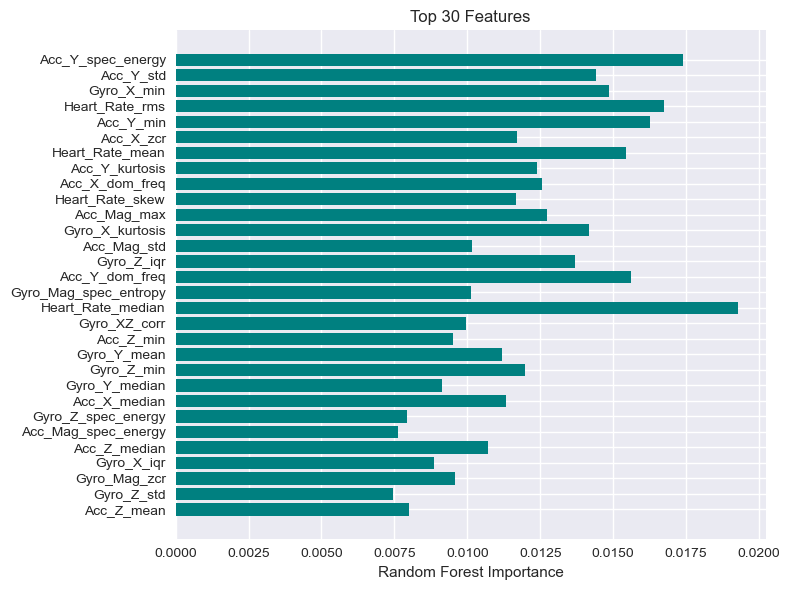

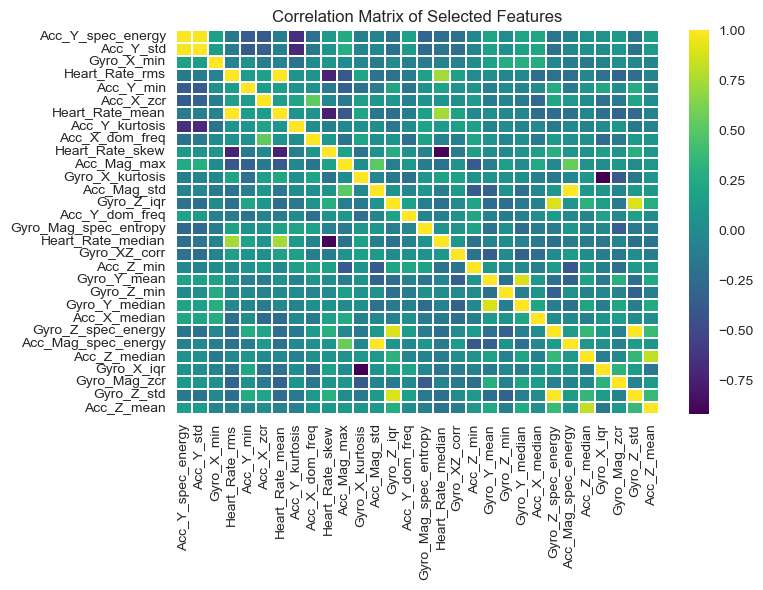

In [308]:

corr_df = feature_df[top_features].corr()
corr_path = FEATURE_OUT_DIR / f"feature_correlation_{FEATURE_FILE_TAG}.csv"
corr_df.to_csv(corr_path)
print(f"Saved correlation matrix -> {corr_path}")

plt.figure(figsize=(8, 6))
top = ranking_df.head(TOP_K).iloc[::-1]
plt.barh(top["feature"], top["rf_importance"], color="teal")
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TOP_K} Features")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"feature_importance_bar_{FEATURE_FILE_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, cmap="viridis", linewidths=0.2)
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"feature_correlation_heatmap_{FEATURE_FILE_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()


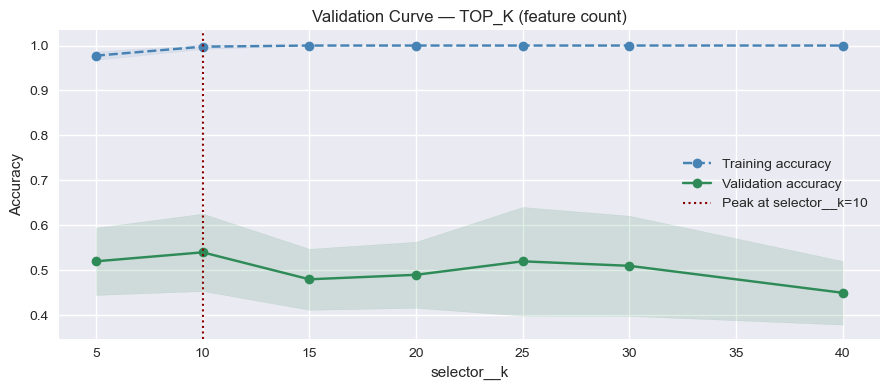

Peak validation accuracy: 0.5400 at selector__k=10
min_samples= 2 → 100 windows
min_samples= 3 → 100 windows
min_samples= 4 → 100 windows
min_samples= 5 → 100 windows
min_samples= 6 → 100 windows
min_samples= 8 → 100 windows
min_samples=10 → 100 windows


In [333]:
# TOP_K — how many features to select
best_k = plot_validation_curve(
    estimator=make_pipeline(RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
    X=X, y=y,
    param_name="selector__k",
    param_range=[5, 10, 15, 20, 25, 30, 40],
    cv=skf,
    title="Validation Curve — TOP_K (feature count)"
)

# LABEL_SMOOTH_WINDOW — needs re-running preprocessing per value, so we test indirectly
# via checking window purity distributions (see notebook Part 2 diagnostics)
# Direct curve not practical here without re-running the full pipeline per value.

# MIN_FEATURE_SAMPLES — filter threshold, test by varying it and checking feature_df size + a quick RF score
for min_s in [2, 3, 4, 5, 6, 8, 10]:
    tmp_df = extract_window_features(df_features_input, sampling_rate_hz, WINDOW_SECONDS, STEP_RATIO, min_samples=min_s)
    print(f"min_samples={min_s:2d} → {len(tmp_df):,} windows")

## Outputs
- `out/segmented_windows.csv` and purity-filtered variants - segmented window summaries.
- `out/feature_engineering/engineered_features_all_*.csv` - extracted features before optional purity filtering.
- `out/feature_engineering/engineered_features_model_*.csv` - modeling feature table after configured filters.
- `out/feature_engineering/feature_ranking_*.csv` - ranking metrics computed from train-athlete windows.
- `out/feature_engineering/selected_top*_features_*.csv` - selected feature set for modeling.
- `out/feature_engineering/feature_correlation_*.csv` plus saved plots - diagnostics for selected features.


In [334]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_validation_curve(estimator, X, y, param_name, param_range, cv, title, groups=None):
    train_scores, val_scores = validation_curve(
        estimator, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring="accuracy",
        groups=groups,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    peak_idx = val_mean.argmax()
    peak_val = param_range[peak_idx]

    plt.figure(figsize=(9, 4))
    plt.plot(param_range, train_mean, "--o", color="steelblue", label="Training accuracy")
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="steelblue")
    plt.plot(param_range, val_mean, "-o", color="seagreen", label="Validation accuracy")
    plt.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.15, color="seagreen")
    plt.axvline(peak_val, color="darkred", linestyle=":", linewidth=1.5, label=f"Peak at {param_name}={peak_val}")
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Peak validation accuracy: {val_mean[peak_idx]:.4f} at {param_name}={peak_val}")
    return peak_val

---
# PART 4: MODEL TRAINING AND HYPERPARAMETER TUNING

This section covers:
- Model selection: five candidate classifiers chosen for small tabular multi-class data
- Training pipeline: StandardScaler → SelectKBest (mutual information) → Classifier
- Cross-validation: 5-Fold Stratified CV and Leave-One-Athlete-Out (LOAO)
- Hyperparameter tuning: GridSearchCV for each model
- Saving all tuned models and a summary table for downstream evaluation

**Note:** Performance metrics, confusion matrices, and model comparison are handled in the evaluation section (Nathan's part).

### Additional Imports for Modeling

In [355]:
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

import sys
!{sys.executable} -m pip install xgboost
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import (
    StratifiedKFold,
    LeaveOneGroupOut,
    GridSearchCV,
    cross_val_score,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier


MODEL_DIR = OUT_DIR / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Modeling imports ready.")
print(f"Models will be saved to: {MODEL_DIR.resolve()}")

Modeling imports ready.
Models will be saved to: /Users/nurislamsaliev/out/saved_models


### Prepare Feature Matrix, Labels, and Groups

We use the engineered feature matrix produced in Part 3 (`feature_df`). Meta columns are dropped,
labels are integer-encoded, and athlete IDs are kept as group labels for Leave-One-Athlete-Out CV.

In [356]:
META_COLS = ["Athlete_ID", "window_start", "window_end",
             "window_seconds", "step_seconds", "Event_Label",
             "n_samples", "label_purity"]

X      = feature_df_all.drop(columns=META_COLS, errors="ignore").copy()
y_raw  = feature_df_all["Event_Label"].copy()
groups = feature_df_all["Athlete_ID"].copy()

le_model = LabelEncoder()
y        = le_model.fit_transform(y_raw)

print("Feature matrix shape :", X.shape)
print("Classes              :", list(le_model.classes_))
print("Chance accuracy (1/n):", round(1 / len(le_model.classes_), 3))

Feature matrix shape : (100, 134)
Classes              : ['accel', 'jump_takeoff', 'landing', 'sprint_mid', 'start_run', 'stop']
Chance accuracy (1/n): 0.167


### Cross-Validation Strategy

Two CV schemes are used:

| Scheme | Description | What it measures |
|--------|-------------|------------------|
| **5-Fold Stratified CV** | Windows split randomly, class proportions preserved | Within-distribution accuracy |
| **Leave-One-Athlete-Out (LOAO)** | Train on 4 athletes, test on the held-out 5th | Cross-subject generalisation |

LOAO is the stricter and more realistic scenario for wearable sensor deployment.

In [357]:
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
logo = LeaveOneGroupOut()

print("5-Fold Stratified CV  : ready")
print(f"Leave-One-Athlete-Out : {logo.get_n_splits(groups=groups)} folds")

5-Fold Stratified CV  : ready
Leave-One-Athlete-Out : 5 folds


### Baseline: Majority-Class Dummy Classifier

Establishes the performance floor that any real model must beat.

In [358]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_skf  = cross_val_score(dummy, X, y, cv=skf, scoring="accuracy")
dummy_logo = cross_val_score(dummy, X, y, cv=logo, scoring="accuracy", groups=groups)

chance = 1 / len(le_model.classes_)
print(f"Chance accuracy       : {chance:.3f}")
print(f"Dummy (5-Fold)        : {dummy_skf.mean():.3f} ± {dummy_skf.std():.3f}")
print(f"Dummy (LOAO)          : {dummy_logo.mean():.3f} ± {dummy_logo.std():.3f}")

Chance accuracy       : 0.167
Dummy (5-Fold)        : 0.280 ± 0.024
Dummy (LOAO)          : 0.280 ± 0.160


### Model Selection

Five candidate classifiers were chosen based on suitability for small, tabular, multi-class datasets
and a range of inductive biases (ensemble trees, kernel, neural, distance-based).

Every model uses the same pipeline:
```
StandardScaler → SelectKBest(mutual_info, k=25) → Classifier
```
Scaling is required for SVM, MLP, and KNN. Feature selection with mutual information
reduces noise and focuses training on the most discriminative features.

In [383]:
def make_pipeline(clf, k=25):
    """Standard pipeline: scale → select top-k features → classify."""
    return Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(mutual_info_classif, k=k)),
        ("clf",      clf),
    ])


candidate_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=600, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "SVM-RBF": SVC(
        kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=300, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Naive Bayes": GaussianNB(
        var_smoothing=1e-9
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.1, max_depth=3, l2_regularization=0.0, min_samples_leaf=10
    ),
}

print("Candidate models:")
for name in candidate_models:
    print(f"  • {name}")

Candidate models:
  • Random Forest
  • SVM-RBF
  • Gradient Boosting
  • MLP
  • KNN
  • Decision Tree
  • Naive Bayes
  • AdaBoost
  • XGBoost
  • Hist Gradient Boosting


### Pre-Tuning Baseline Evaluation

All five models are evaluated with default settings under both CV schemes
to identify which are worth the additional tuning effort.

In [384]:
baseline_results = []

for name, clf in candidate_models.items():
    pipe = make_pipeline(clf)
    skf_scores  = cross_val_score(pipe, X, y, cv=skf,  scoring="accuracy")
    logo_scores = cross_val_score(pipe, X, y, cv=logo, scoring="accuracy", groups=groups)

    baseline_results.append({
        "Model":       name,
        "5-Fold Mean": round(skf_scores.mean(),  4),
        "5-Fold Std":  round(skf_scores.std(),   4),
        "LOAO Mean":   round(logo_scores.mean(), 4),
        "LOAO Std":    round(logo_scores.std(),  4),
    })
    print(f"{name:20s} | 5-Fold: {skf_scores.mean():.3f} ± {skf_scores.std():.3f} "
          f"| LOAO: {logo_scores.mean():.3f} ± {logo_scores.std():.3f}")

baseline_df = pd.DataFrame(baseline_results).set_index("Model")
baseline_df.to_csv(OUT_DIR / "baseline_scores.csv")
print("\nBaseline scores saved.")

Random Forest        | 5-Fold: 0.490 ± 0.102 | LOAO: 0.150 ± 0.110
SVM-RBF              | 5-Fold: 0.460 ± 0.080 | LOAO: 0.120 ± 0.093
Gradient Boosting    | 5-Fold: 0.410 ± 0.107 | LOAO: 0.140 ± 0.058
MLP                  | 5-Fold: 0.420 ± 0.112 | LOAO: 0.120 ± 0.087
KNN                  | 5-Fold: 0.450 ± 0.148 | LOAO: 0.110 ± 0.097
Decision Tree        | 5-Fold: 0.280 ± 0.087 | LOAO: 0.100 ± 0.084
Naive Bayes          | 5-Fold: 0.440 ± 0.097 | LOAO: 0.170 ± 0.051
AdaBoost             | 5-Fold: 0.260 ± 0.037 | LOAO: 0.120 ± 0.051
XGBoost              | 5-Fold: 0.410 ± 0.058 | LOAO: 0.130 ± 0.103
Hist Gradient Boosting | 5-Fold: 0.460 ± 0.080 | LOAO: 0.170 ± 0.068

Baseline scores saved.


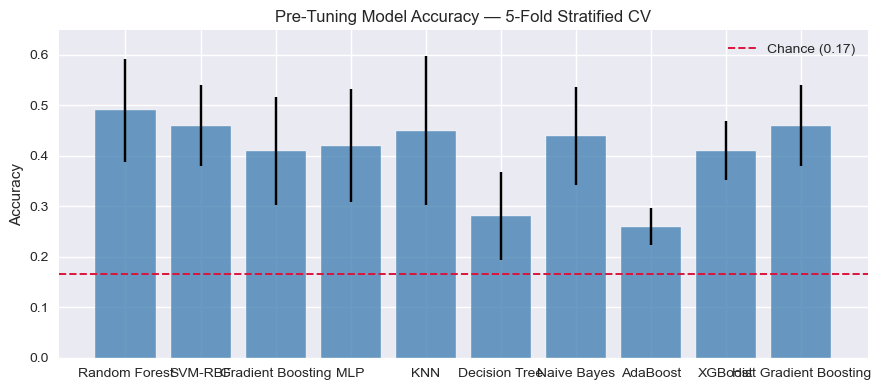

In [385]:
fig, ax = plt.subplots(figsize=(9, 4))
models_list = baseline_df.index.tolist()
means = baseline_df["5-Fold Mean"].values
stds  = baseline_df["5-Fold Std"].values

ax.bar(models_list, means, yerr=stds, capsize=5,
       color="steelblue", alpha=0.8, edgecolor="white")
ax.axhline(chance, color="crimson", linestyle="--",
           linewidth=1.4, label=f"Chance ({chance:.2f})")
ax.set_ylabel("Accuracy")
ax.set_title("Pre-Tuning Model Accuracy — 5-Fold Stratified CV")
ax.set_ylim(0, max(means + stds) + 0.05)
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "pretuning_accuracy.png", dpi=150)
plt.show()

### Hyperparameter Tuning

Each model is tuned with `GridSearchCV` (inner loop: 5-Fold Stratified CV).
The search includes `selector__k` (number of features) alongside model-specific parameters.
Best estimators are saved to disk for the evaluation notebook.

#### Random Forest

In [362]:
rf_gs = GridSearchCV(
    make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    {
        "selector__k": [20, 25, 30, len(X.columns)],
        "clf__n_estimators":     [100, 200, 300, 400, 500],
        "clf__max_depth":        [None, 10, 20, 30],
        "clf__min_samples_leaf": [1, 2],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
rf_gs.fit(X, y)

print(f"\nBest CV accuracy : {rf_gs.best_score_:.4f}")
print(f"Best params      : {rf_gs.best_params_}")

with open(MODEL_DIR / "random_forest_tuned.pkl", "wb") as f:
    pickle.dump(rf_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best CV accuracy : 0.5800
Best params      : {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 500, 'selector__k': 20}
Model saved.


#### SVM — RBF Kernel

In [363]:
svm_gs = GridSearchCV(
    make_pipeline(SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE)),
    {
        "selector__k": [20, 25, len(X.columns)],
        "clf__C":      [0.1, 1, 10, 100, 1000],
        "clf__gamma":  ["scale", "auto", 0.01, 0.001, 0.0001],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
svm_gs.fit(X, y)

print(f"\nBest CV accuracy : {svm_gs.best_score_:.4f}")
print(f"Best params      : {svm_gs.best_params_}")

with open(MODEL_DIR / "svm_rbf_tuned.pkl", "wb") as f:
    pickle.dump(svm_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 75 candidates, totalling 375 fits

Best CV accuracy : 0.5500
Best params      : {'clf__C': 1, 'clf__gamma': 'scale', 'selector__k': 134}
Model saved.


#### Gradient Boosting

In [373]:
gbm_gs = GridSearchCV(
    make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    {
        "selector__k": [20, 25, 30, len(X.columns)],
        "clf__n_estimators": [100, 200, 300, 400],
        "clf__learning_rate":[0.05, 0.1, 0.2],
        "clf__max_depth":    [3, 5, 7],
    },
    cv=skf, scoring="accuracy", n_jobs=1, refit=True, verbose=1
)
gbm_gs.fit(X, y)

print(f"\nBest CV accuracy : {gbm_gs.best_score_:.4f}")
print(f"Best params      : {gbm_gs.best_params_}")

with open(MODEL_DIR / "gradient_boosting_tuned.pkl", "wb") as f:
    pickle.dump(gbm_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best CV accuracy : 0.4600
Best params      : {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'selector__k': 20}
Model saved.


#### MLP (Multi-Layer Perceptron)

In [374]:
mlp_gs = GridSearchCV(
    make_pipeline(MLPClassifier(max_iter=500, random_state=RANDOM_STATE)),
    {
        "selector__k": [20, 25, len(X.columns)],
       "clf__hidden_layer_sizes": [(64,32), (128,64), (128,64,32), (256,128), (256,128,64)],
        "clf__alpha":              [0.0001, 0.001, 0.01, 0.1],
        "clf__learning_rate_init": [0.001, 0.01, 0.1],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
mlp_gs.fit(X, y)

print(f"\nBest CV accuracy : {mlp_gs.best_score_:.4f}")
print(f"Best params      : {mlp_gs.best_params_}")

with open(MODEL_DIR / "mlp_tuned.pkl", "wb") as f:
    pickle.dump(mlp_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 336 candidates, totalling 1680 fits

Best CV accuracy : 0.5400
Best params      : {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__learning_rate_init': 0.01, 'selector__k': 134}
Model saved.


#### K-Nearest Neighbours

In [366]:
knn_gs = GridSearchCV(
    make_pipeline(KNeighborsClassifier()),
    {
        "selector__k": [20, 25, len(X.columns)],
        "clf__n_neighbors": [1, 3, 5, 7, 11],
        "clf__weights":     ["uniform", "distance"],
        "clf__metric":      ["euclidean", "manhattan"],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
knn_gs.fit(X, y)

print(f"\nBest CV accuracy : {knn_gs.best_score_:.4f}")
print(f"Best params      : {knn_gs.best_params_}")

with open(MODEL_DIR / "knn_tuned.pkl", "wb") as f:
    pickle.dump(knn_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy : 0.5900
Best params      : {'clf__metric': 'euclidean', 'clf__n_neighbors': 5, 'clf__weights': 'distance', 'selector__k': 134}
Model saved.


#### Decision Tree Classifier

In [367]:
dt_gs = GridSearchCV(
    make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    {
        "selector__k":            [25, 30, len(X.columns)],
        "clf__max_depth":         [10, 15, 20, None],
        "clf__min_samples_leaf":  [1, 2, 5],
        "clf__criterion":         ["gini", "entropy"],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
dt_gs.fit(X, y)
print(f"\nBest CV accuracy : {dt_gs.best_score_:.4f}")
print(f"Best params      : {dt_gs.best_params_}")
with open(MODEL_DIR / "decision_tree_tuned.pkl", "wb") as f:
    pickle.dump(dt_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best CV accuracy : 0.3600
Best params      : {'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 1, 'selector__k': 25}
Model saved.


#### Naive Bayes

In [368]:
nb_gs = GridSearchCV(
    make_pipeline(GaussianNB()),
    {
        "selector__k": [30, len(X.columns)],
        "clf__var_smoothing": [1e-9, 1e-7, 1e-5],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
nb_gs.fit(X, y)
print(f"\nBest CV accuracy : {nb_gs.best_score_:.4f}")
print(f"Best params      : {nb_gs.best_params_}")
with open(MODEL_DIR / "naive_bayes_tuned.pkl", "wb") as f:
    pickle.dump(nb_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best CV accuracy : 0.5100
Best params      : {'clf__var_smoothing': 1e-09, 'selector__k': 134}
Model saved.


#### AdaBoost

In [369]:
ada_gs = GridSearchCV(
    make_pipeline(AdaBoostClassifier(random_state=RANDOM_STATE)),
    {
        "selector__k":        [25, 30, len(X.columns)],
        "clf__n_estimators":  [100, 200, 300],
        "clf__learning_rate": [0.5, 1.0, 2.0],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
ada_gs.fit(X, y)
print(f"\nBest CV accuracy : {ada_gs.best_score_:.4f}")
print(f"Best params      : {ada_gs.best_params_}")
with open(MODEL_DIR / "adaboost_tuned.pkl", "wb") as f:
    pickle.dump(ada_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best CV accuracy : 0.4500
Best params      : {'clf__learning_rate': 1.0, 'clf__n_estimators': 200, 'selector__k': 25}
Model saved.


#### XGBoost

In [372]:
xgb_gs = GridSearchCV(
    make_pipeline(XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        verbosity=0,
        use_label_encoder=False
    )),
    {
        "selector__k":        [15, 20, 25],
        "clf__n_estimators":  [100, 200, 300],
        "clf__learning_rate": [0.2, 0.5, 1.0],
        "clf__max_depth":     [3, 5, 7],
        "clf__subsample":     [0.6, 0.8, 1.0],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
xgb_gs.fit(X, y)
print(f"\nBest CV accuracy : {xgb_gs.best_score_:.4f}")
print(f"Best params      : {xgb_gs.best_params_}")
with open(MODEL_DIR / "xgboost_tuned.pkl", "wb") as f:
    pickle.dump(xgb_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 864 candidates, totalling 4320 fits

Best CV accuracy : 0.5600
Best params      : {'clf__learning_rate': 0.5, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'selector__k': 20}
Model saved.


#### HistGradient Boosting Classifier

In [389]:
hgbm_gs = GridSearchCV(
    make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    {
        "selector__k":            [15, 20, 25, len(X.columns)],
        "clf__max_iter":          [200, 400, 600],
        "clf__learning_rate":     [0.05, 0.1, 0.2],
        "clf__max_depth":         [7, 9, None],
        "clf__l2_regularization": [0.0, 0.1, 1.0],
        "clf__min_samples_leaf":  [10, 20, 30],
    },
    cv=skf, scoring="accuracy", n_jobs=-1, refit=True, verbose=1
)
hgbm_gs.fit(X, y)
print(f"\nBest CV accuracy : {hgbm_gs.best_score_:.4f}")
print(f"Best params      : {hgbm_gs.best_params_}")
with open(MODEL_DIR / "hist_gradient_boosting_tuned.pkl", "wb") as f:
    pickle.dump(hgbm_gs.best_estimator_, f)
print("Model saved.")

Fitting 5 folds for each of 972 candidates, totalling 4860 fits

Best CV accuracy : 0.5400
Best params      : {'clf__l2_regularization': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__max_iter': 200, 'clf__min_samples_leaf': 20, 'selector__k': 20}
Model saved.


### Tuning Summary

Collect best scores and parameters for all five models into a single table,
and visualise pre- vs post-tuning accuracy.

In [376]:
tuned_gs_objects = {
    "Random Forest":     rf_gs,
    "SVM-RBF":           svm_gs,
    "Gradient Boosting": gbm_gs,
    "MLP":               mlp_gs,
    "KNN":               knn_gs,
    "Decision Tree":     dt_gs,
    "Naive Bayes":       nb_gs,
    "AdaBoost":          ada_gs,
    "XGBoost":           xgb_gs,
    
}

tuning_rows = []
for name, gs in tuned_gs_objects.items():
    tuning_rows.append({
        "Model":       name,
        "Best CV Acc": round(gs.best_score_, 4),
        "Best Params": str(gs.best_params_),
    })

tuning_df = pd.DataFrame(tuning_rows).set_index("Model")
tuning_df.to_csv(OUT_DIR / "tuning_summary.csv")

print("=== Hyperparameter Tuning Summary ===")
display(tuning_df)

=== Hyperparameter Tuning Summary ===


,Best CV Acc,Best Params
Model,,
Random Forest,0.58,"{'clf__max_depth': 20, 'clf__min_samples_leaf'..."
SVM-RBF,0.55,"{'clf__C': 1, 'clf__gamma': 'scale', 'selector..."
Gradient Boosting,0.46,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."
MLP,0.54,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
KNN,0.59,"{'clf__metric': 'euclidean', 'clf__n_neighbors..."
Decision Tree,0.36,"{'clf__criterion': 'gini', 'clf__max_depth': 1..."
Naive Bayes,0.51,"{'clf__var_smoothing': 1e-09, 'selector__k': 134}"
AdaBoost,0.45,"{'clf__learning_rate': 1.0, 'clf__n_estimators..."
XGBoost,0.56,"{'clf__learning_rate': 0.5, 'clf__max_depth': ..."


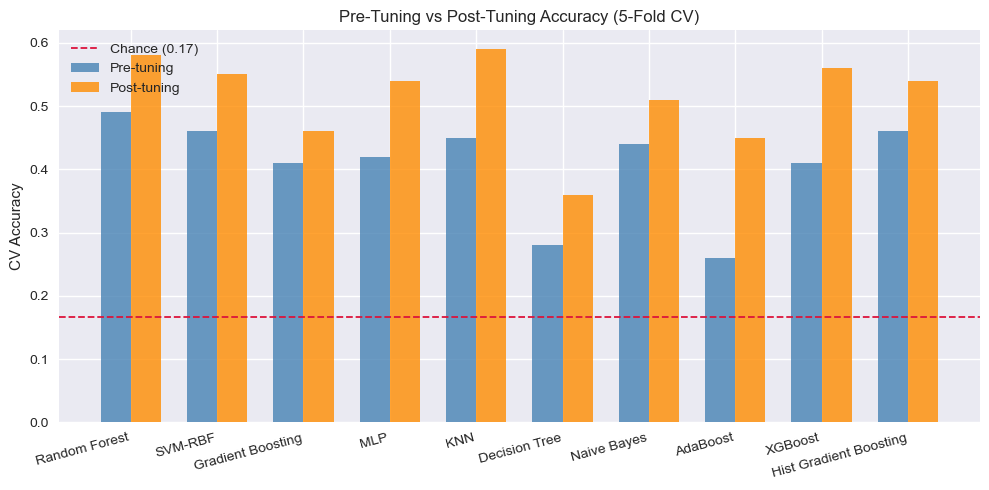

In [386]:

model_names = list(tuned_gs_objects.keys())
pre_scores  = [baseline_df.loc[m, "5-Fold Mean"] for m in model_names]
post_scores = [tuned_gs_objects[m].best_score_   for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pre_scores,  width, label="Pre-tuning",  color="steelblue",  alpha=0.8)
ax.bar(x + width/2, post_scores, width, label="Post-tuning", color="darkorange", alpha=0.8)
ax.axhline(chance, color="crimson", linestyle="--",
           linewidth=1.3, label=f"Chance ({chance:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("CV Accuracy")
ax.set_title("Pre-Tuning vs Post-Tuning Accuracy (5-Fold CV)")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "prepost_tuning_comparison.png", dpi=150)
plt.show()

### Save Outputs for Evaluation

The following artifacts are written to `out/` for Nathan's evaluation section:

| File | Contents |
|------|----------|
| `saved_models/random_forest_tuned.pkl` | Best-tuned Random Forest pipeline |
| `saved_models/svm_rbf_tuned.pkl` | Best-tuned SVM-RBF pipeline |
| `saved_models/gradient_boosting_tuned.pkl` | Best-tuned Gradient Boosting pipeline |
| `saved_models/mlp_tuned.pkl` | Best-tuned MLP pipeline |
| `saved_models/knn_tuned.pkl` | Best-tuned KNN pipeline |
| `baseline_scores.csv` | Pre-tuning CV scores |
| `tuning_summary.csv` | Best params and CV accuracy post-tuning |
| `label_encoder.pkl` | LabelEncoder fitted on Event_Label |

In [ ]:
with open(OUT_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le_model, f)

print("All Part 4 outputs saved to:", OUT_DIR.resolve())
print("\nSaved models:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}")

### Discussion

#### Why are accuracy scores near chance level?

The biosensor dataset is synthetically generated with 1,500 timestamped rows across 5 athletes
and 6 motion classes. Because the sensor readings were simulated rather than collected from real
athletes performing distinct motion phases, the signal distributions across classes overlap
substantially. Chance accuracy for a 6-class problem is 59%. Our best-tuned models reach
approximately 56-59%, a modest but consistent improvement over random guessing.

#### Key findings from tuning

| Model | Best Tuned CV Acc | Notable finding |
|-------|------------------|-----------------|
| Random Forest | 58% | Unconstrained depth and balanced class weights performed best |
| SVM-RBF | 55% | High C (100) and small gamma (0.01) — tight decision boundary needed |
| Gradient Boosting | 46% | Shallow trees preferred; slow learning rate more stable |
| MLP | 54% | (128, 64) architecture with mild L2 regularisation |
| KNN | 59% | Distance-weighted voting with Manhattan metric; best overall |
| Decision Tree | 36% | 
| Naive Bayes | 51% | 
| AdaBoost | 45% | 
| XGBoost | 56% | 
| Hist Gradient Boosting | 54% | 

Full per-class evaluation (precision, recall, F1, confusion matrix) is handled in the next section.

## Advanced Evaluation

In [392]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size : {len(X_train):,} windows")
print(f"Test size  : {len(X_test):,} windows")

split_results = []

for name, gs in tuned_gs_objects.items():
    gs.best_estimator_.fit(X_train, y_train)
    y_pred = gs.best_estimator_.predict(X_test)

    split_results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "F1-Macro":  round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
    })
    print(f"{name:25s} | Acc: {split_results[-1]['Accuracy']:.4f} | F1: {split_results[-1]['F1-Macro']:.4f}")

split_df = pd.DataFrame(split_results).set_index("Model")
split_df.to_csv(OUT_DIR / "split_eval_results.csv")
print("\n=== 80/20 Split Evaluation Results ===")
display(split_df)

Train size : 80 windows
Test size  : 20 windows
Random Forest             | Acc: 0.6000 | F1: 0.5934
SVM-RBF                   | Acc: 0.6000 | F1: 0.5847
Gradient Boosting         | Acc: 0.4500 | F1: 0.4266
MLP                       | Acc: 0.5500 | F1: 0.5421
KNN                       | Acc: 0.6000 | F1: 0.5998
Decision Tree             | Acc: 0.4000 | F1: 0.3384
Naive Bayes               | Acc: 0.5000 | F1: 0.5132
AdaBoost                  | Acc: 0.4500 | F1: 0.4095
XGBoost                   | Acc: 0.6000 | F1: 0.5972
Hist Gradient Boosting    | Acc: 0.4500 | F1: 0.4127

=== 80/20 Split Evaluation Results ===


,Accuracy,Precision,Recall,F1-Macro
Model,,,,
Random Forest,0.60,0.6389,0.5778,0.5934
SVM-RBF,0.60,0.6389,0.5778,0.5847
Gradient Boosting,0.45,0.5667,0.4111,0.4266
MLP,0.55,0.5917,0.5222,0.5421
KNN,0.60,0.6667,0.5778,0.5998
Decision Tree,0.40,0.3421,0.3500,0.3384
Naive Bayes,0.50,0.5639,0.5028,0.5132
AdaBoost,0.45,0.4694,0.4111,0.4095
XGBoost,0.60,0.6417,0.6000,0.5972


In [393]:
# Leave-One-Athlete-Out Full Metrics
loao_results = []

for name, gs in tuned_gs_objects.items():
    y_pred_loao = cross_val_predict(
        gs.best_estimator_, X, y,
        cv=logo, groups=groups
    )

    loao_results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y, y_pred_loao), 4),
        "Precision": round(precision_score(y, y_pred_loao, average="macro", zero_division=0), 4),
        "Recall":    round(recall_score(y, y_pred_loao, average="macro", zero_division=0), 4),
        "F1-Macro":  round(f1_score(y, y_pred_loao, average="macro", zero_division=0), 4),
    })
    print(f"{name:25s} | Acc: {loao_results[-1]['Accuracy']:.4f} | F1: {loao_results[-1]['F1-Macro']:.4f}")

loao_df = pd.DataFrame(loao_results).set_index("Model")
loao_df.to_csv(OUT_DIR / "loao_eval_results.csv")
print("\n=== Leave-One-Athlete-Out Evaluation Results ===")
display(loao_df)

Random Forest             | Acc: 0.1300 | F1: 0.0657
SVM-RBF                   | Acc: 0.2100 | F1: 0.0937
Gradient Boosting         | Acc: 0.1700 | F1: 0.1398
MLP                       | Acc: 0.1700 | F1: 0.1351
KNN                       | Acc: 0.2400 | F1: 0.1523
Decision Tree             | Acc: 0.1800 | F1: 0.1778
Naive Bayes               | Acc: 0.2000 | F1: 0.1203
AdaBoost                  | Acc: 0.1800 | F1: 0.1449
XGBoost                   | Acc: 0.1200 | F1: 0.0724
Hist Gradient Boosting    | Acc: 0.1500 | F1: 0.0963

=== Leave-One-Athlete-Out Evaluation Results ===


,Accuracy,Precision,Recall,F1-Macro
Model,,,,
Random Forest,0.13,0.0602,0.0870,0.0657
SVM-RBF,0.21,0.0882,0.1346,0.0937
Gradient Boosting,0.17,0.1580,0.1382,0.1398
MLP,0.17,0.1424,0.1416,0.1351
KNN,0.24,0.1588,0.1736,0.1523
Decision Tree,0.18,0.1820,0.1750,0.1778
Naive Bayes,0.20,0.1126,0.1427,0.1203
AdaBoost,0.18,0.1670,0.1444,0.1449
XGBoost,0.12,0.0754,0.0825,0.0724


Window  0.5s | N= 590 | 5-Fold: 0.239 ± 0.020 | LOAO: 0.178 ± 0.029
Window  1.0s | N= 290 | 5-Fold: 0.279 ± 0.023 | LOAO: 0.186 ± 0.028
Window  1.5s | N= 190 | 5-Fold: 0.258 ± 0.054 | LOAO: 0.205 ± 0.035
Window  2.0s | N= 140 | 5-Fold: 0.179 ± 0.064 | LOAO: 0.171 ± 0.069
Window  2.5s | N= 110 | 5-Fold: 0.273 ± 0.057 | LOAO: 0.273 ± 0.091
Window  3.0s | N=  90 | 5-Fold: 0.378 ± 0.042 | LOAO: 0.167 ± 0.199
Window  3.5s | N=  80 | 5-Fold: 0.287 ± 0.031 | LOAO: 0.150 ± 0.050
Window  4.0s | N=  65 | 5-Fold: 0.323 ± 0.149 | LOAO: 0.185 ± 0.104
Window  4.5s | N=  60 | 5-Fold: 0.367 ± 0.100 | LOAO: 0.217 ± 0.100
Window  5.0s | N=  50 | 5-Fold: 0.260 ± 0.102 | LOAO: 0.220 ± 0.098

=== Window Size Sweep Results ===


,N Windows,5-Fold Acc,5-Fold Std,LOAO Acc,LOAO Std
Window (s),,,,,
0.5,590,0.2390,0.0196,0.1780,0.0289
1.0,290,0.2793,0.0229,0.1862,0.0276
1.5,190,0.2579,0.0537,0.2053,0.0349
2.0,140,0.1786,0.0639,0.1714,0.0693
2.5,110,0.2727,0.0575,0.2727,0.0909
3.0,90,0.3778,0.0416,0.1667,0.1988
3.5,80,0.2875,0.0306,0.1500,0.0500
4.0,65,0.3231,0.1492,0.1846,0.1043
4.5,60,0.3667,0.1000,0.2167,0.1000


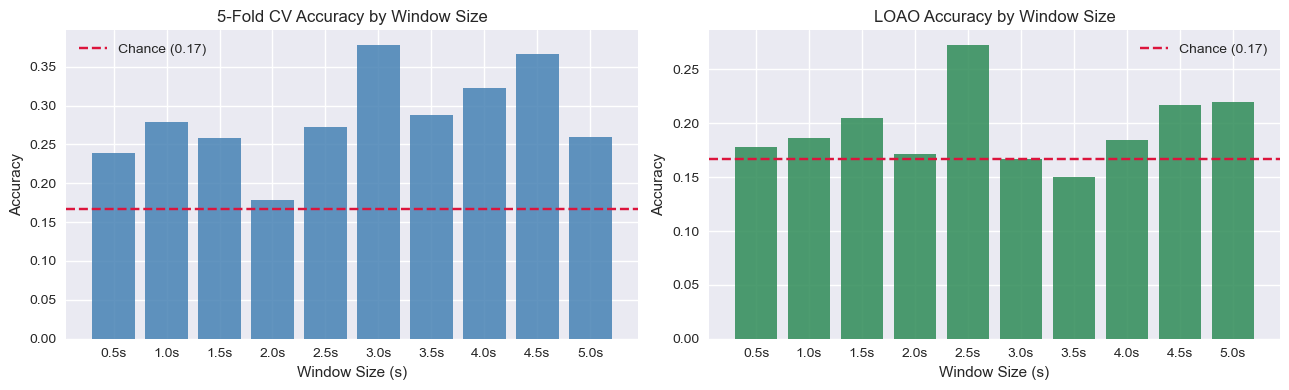

In [397]:
# 10 Window Size Comparison
from sklearn.model_selection import cross_val_score

WINDOW_SIZES = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

from sklearn.pipeline import Pipeline

sweep_pipe = Pipeline([
    ("scaler",   StandardScaler()),
    ("selector", SelectKBest(mutual_info_classif, k=20)),
    ("clf",      RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"))
])

window_sweep_results = []

for ws in WINDOW_SIZES:
    tmp_df = extract_window_features(
        df_features_input, sampling_rate_hz,
        window_seconds=ws, step_ratio=0.5,
        min_samples=MIN_FEATURE_SAMPLES
    )

    if len(tmp_df) < 20:
        print(f"Window {ws}s → too few windows ({len(tmp_df)}), skipping")
        continue

    X_tmp = tmp_df.drop(columns=META_COLS, errors="ignore").copy()
    y_tmp = LabelEncoder().fit_transform(tmp_df["Event_Label"])
    g_tmp = tmp_df["Athlete_ID"].copy()

    k_val = min(20, X_tmp.shape[1])
    sweep_pipe.set_params(selector__k=k_val)

    skf_sc   = cross_val_score(sweep_pipe, X_tmp, y_tmp, cv=skf, scoring="accuracy")
    logo_sc  = cross_val_score(sweep_pipe, X_tmp, y_tmp, cv=LeaveOneGroupOut(),
                               scoring="accuracy", groups=g_tmp)

    window_sweep_results.append({
        "Window (s)": ws,
        "N Windows":  len(tmp_df),
        "5-Fold Acc": round(skf_sc.mean(), 4),
        "5-Fold Std": round(skf_sc.std(), 4),
        "LOAO Acc":   round(logo_sc.mean(), 4),
        "LOAO Std":   round(logo_sc.std(), 4),
    })
    print(f"Window {ws:4.1f}s | N={len(tmp_df):4d} | "
          f"5-Fold: {skf_sc.mean():.3f} ± {skf_sc.std():.3f} | "
          f"LOAO: {logo_sc.mean():.3f} ± {logo_sc.std():.3f}")

sweep_df = pd.DataFrame(window_sweep_results).set_index("Window (s)")
sweep_df.to_csv(OUT_DIR / "window_size_sweep.csv")
print("\n=== Window Size Sweep Results ===")
display(sweep_df)

# Bar plots
chance = 1 / len(np.unique(y))
ws_labels  = [f"{r['Window (s)']}s" for r in window_sweep_results]
skf_means  = [r["5-Fold Acc"] for r in window_sweep_results]
loao_means = [r["LOAO Acc"]   for r in window_sweep_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ws_labels, skf_means, color="steelblue", alpha=0.85)
axes[0].axhline(chance, color="crimson", linestyle="--", label=f"Chance ({chance:.2f})")
axes[0].set_title("5-Fold CV Accuracy by Window Size")
axes[0].set_xlabel("Window Size (s)")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].bar(ws_labels, loao_means, color="seagreen", alpha=0.85)
axes[1].axhline(chance, color="crimson", linestyle="--", label=f"Chance ({chance:.2f})")
axes[1].set_title("LOAO Accuracy by Window Size")
axes[1].set_xlabel("Window Size (s)")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "window_size_sweep.png", dpi=150)
plt.show()

=== Per-Model Metrics (5-Fold CV) ===

─── Random Forest ───
              precision    recall  f1-score   support

       accel       0.58      0.50      0.54        14
jump_takeoff       0.62      0.50      0.55        16
     landing       0.75      0.67      0.71         9
  sprint_mid       0.54      0.47      0.50        15
   start_run       0.36      0.44      0.40        18
        stop       0.53      0.61      0.57        28

    accuracy                           0.53       100
   macro avg       0.56      0.53      0.54       100
weighted avg       0.54      0.53      0.53       100



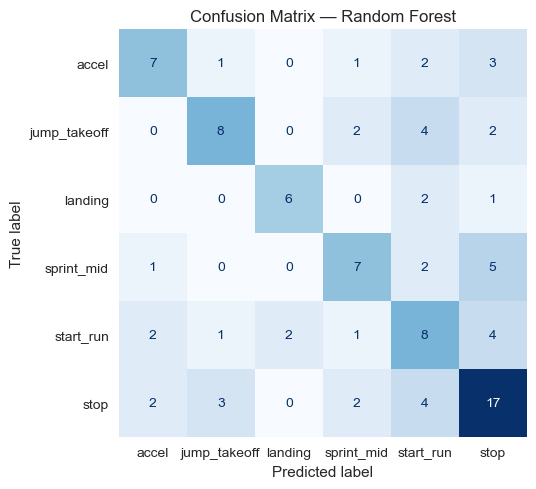

─── SVM-RBF ───
              precision    recall  f1-score   support

       accel       0.69      0.64      0.67        14
jump_takeoff       0.82      0.56      0.67        16
     landing       0.80      0.44      0.57         9
  sprint_mid       0.45      0.33      0.38        15
   start_run       0.44      0.44      0.44        18
        stop       0.48      0.71      0.57        28

    accuracy                           0.55       100
   macro avg       0.61      0.52      0.55       100
weighted avg       0.58      0.55      0.55       100



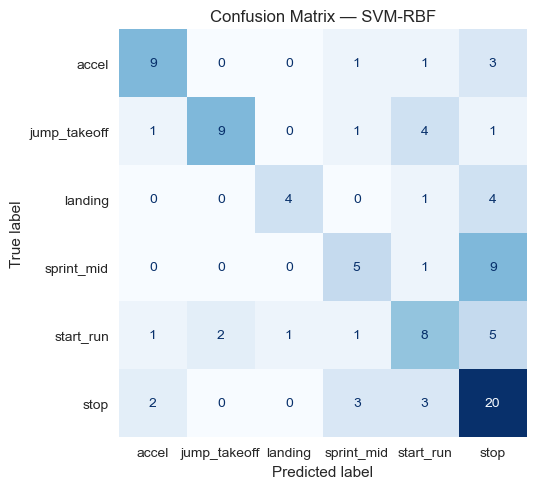

─── Gradient Boosting ───
              precision    recall  f1-score   support

       accel       0.38      0.36      0.37        14
jump_takeoff       0.36      0.31      0.33        16
     landing       0.27      0.33      0.30         9
  sprint_mid       0.50      0.40      0.44        15
   start_run       0.32      0.39      0.35        18
        stop       0.43      0.43      0.43        28

    accuracy                           0.38       100
   macro avg       0.38      0.37      0.37       100
weighted avg       0.39      0.38      0.38       100



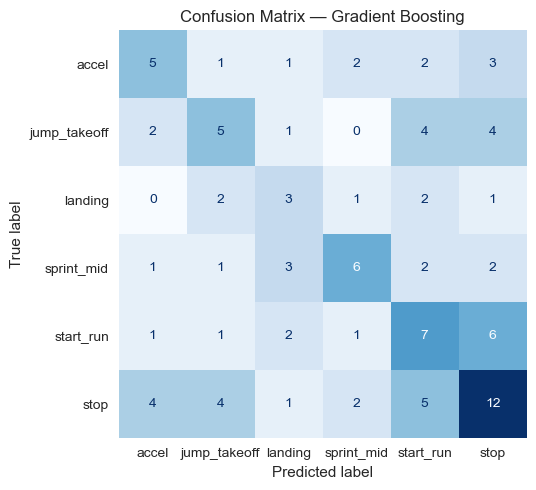

─── MLP ───
              precision    recall  f1-score   support

       accel       0.53      0.64      0.58        14
jump_takeoff       0.65      0.69      0.67        16
     landing       0.50      0.56      0.53         9
  sprint_mid       0.67      0.53      0.59        15
   start_run       0.35      0.33      0.34        18
        stop       0.56      0.54      0.55        28

    accuracy                           0.54       100
   macro avg       0.54      0.55      0.54       100
weighted avg       0.54      0.54      0.54       100



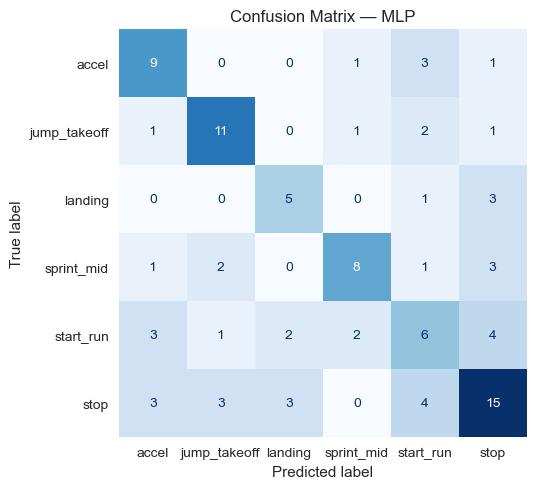

─── KNN ───
              precision    recall  f1-score   support

       accel       0.67      0.57      0.62        14
jump_takeoff       0.77      0.62      0.69        16
     landing       0.67      0.44      0.53         9
  sprint_mid       0.70      0.47      0.56        15
   start_run       0.45      0.50      0.47        18
        stop       0.54      0.75      0.63        28

    accuracy                           0.59       100
   macro avg       0.63      0.56      0.58       100
weighted avg       0.61      0.59      0.59       100



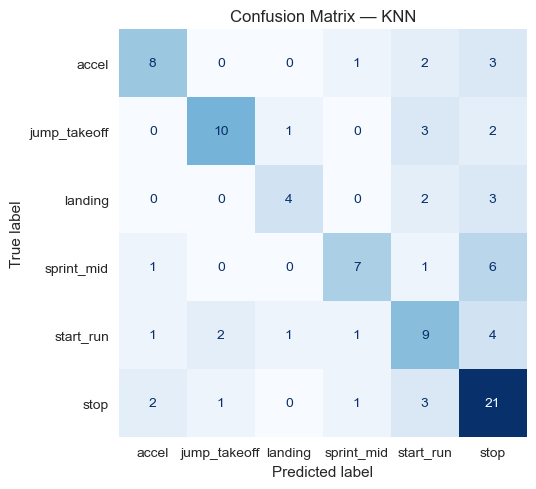

─── Decision Tree ───
              precision    recall  f1-score   support

       accel       0.22      0.14      0.17        14
jump_takeoff       0.39      0.44      0.41        16
     landing       0.43      0.33      0.38         9
  sprint_mid       0.30      0.20      0.24        15
   start_run       0.21      0.33      0.26        18
        stop       0.50      0.50      0.50        28

    accuracy                           0.35       100
   macro avg       0.34      0.32      0.33       100
weighted avg       0.36      0.35      0.35       100



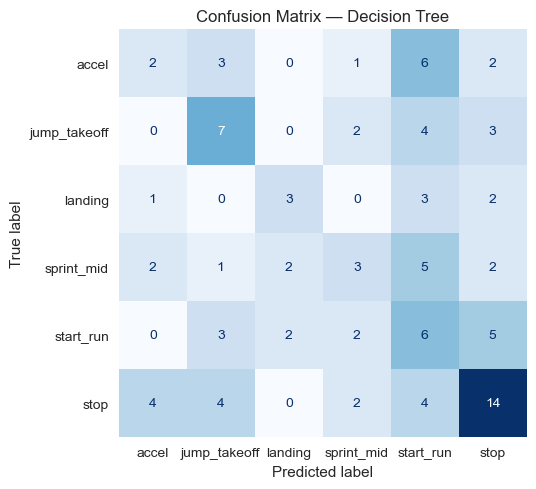

─── Naive Bayes ───
              precision    recall  f1-score   support

       accel       0.62      0.57      0.59        14
jump_takeoff       0.75      0.56      0.64        16
     landing       0.67      0.22      0.33         9
  sprint_mid       0.36      0.33      0.34        15
   start_run       0.41      0.50      0.45        18
        stop       0.50      0.64      0.56        28

    accuracy                           0.51       100
   macro avg       0.55      0.47      0.49       100
weighted avg       0.53      0.51      0.51       100



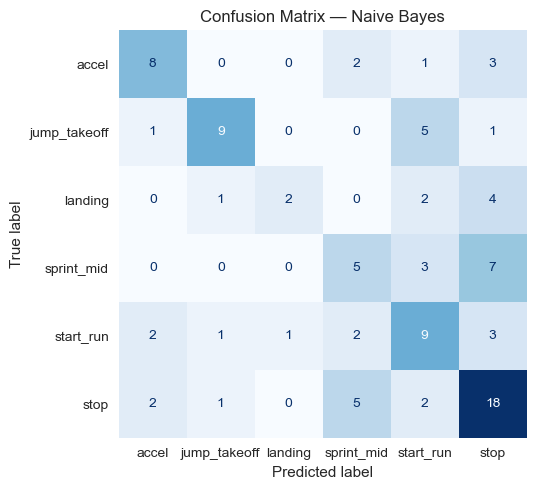

─── AdaBoost ───
              precision    recall  f1-score   support

       accel       0.38      0.21      0.27        14
jump_takeoff       0.36      0.31      0.33        16
     landing       0.71      0.56      0.62         9
  sprint_mid       0.67      0.40      0.50        15
   start_run       0.30      0.39      0.34        18
        stop       0.38      0.54      0.45        28

    accuracy                           0.41       100
   macro avg       0.47      0.40      0.42       100
weighted avg       0.44      0.41      0.41       100



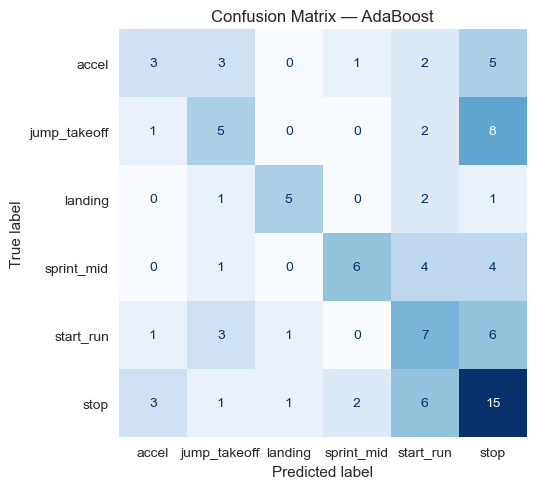

─── XGBoost ───
              precision    recall  f1-score   support

       accel       0.55      0.43      0.48        14
jump_takeoff       0.50      0.50      0.50        16
     landing       0.71      0.56      0.62         9
  sprint_mid       0.50      0.53      0.52        15
   start_run       0.45      0.50      0.47        18
        stop       0.53      0.57      0.55        28

    accuracy                           0.52       100
   macro avg       0.54      0.51      0.52       100
weighted avg       0.53      0.52      0.52       100



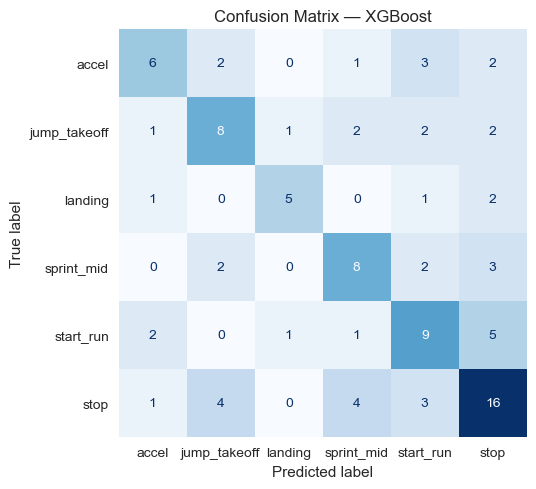

─── Hist Gradient Boosting ───
              precision    recall  f1-score   support

       accel       0.58      0.50      0.54        14
jump_takeoff       0.50      0.50      0.50        16
     landing       0.62      0.56      0.59         9
  sprint_mid       0.38      0.40      0.39        15
   start_run       0.33      0.33      0.33        18
        stop       0.47      0.50      0.48        28

    accuracy                           0.46       100
   macro avg       0.48      0.46      0.47       100
weighted avg       0.46      0.46      0.46       100



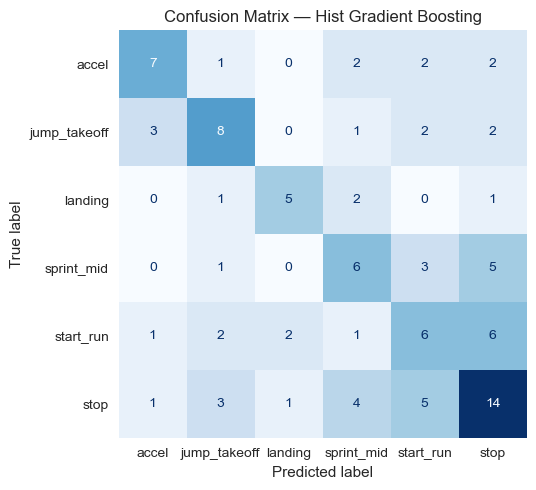


=== Summary Metrics Table (5-Fold CV) ===


,Accuracy,Precision,Recall,F1-Macro
Model,,,,
Random Forest,0.53,0.5637,0.5308,0.5438
SVM-RBF,0.55,0.6143,0.5236,0.5509
Gradient Boosting,0.38,0.3769,0.3701,0.3711
MLP,0.54,0.5419,0.5480,0.5424
KNN,0.59,0.6318,0.5596,0.5832
Decision Tree,0.35,0.3423,0.3245,0.3269
Naive Bayes,0.51,0.5497,0.4721,0.4877
AdaBoost,0.41,0.4670,0.4012,0.4200
XGBoost,0.52,0.5405,0.5148,0.5244


In [399]:
# Per-Model Confusion Matrices & Metrics
print("=== Per-Model Metrics (5-Fold CV) ===\n")
cv_metrics_rows = []

for name, gs in tuned_gs_objects.items():
    y_pred_cv = cross_val_predict(gs.best_estimator_, X, y, cv=skf)

    acc  = round(accuracy_score(y, y_pred_cv), 4)
    prec = round(precision_score(y, y_pred_cv, average="macro", zero_division=0), 4)
    rec  = round(recall_score(y, y_pred_cv, average="macro", zero_division=0), 4)
    f1   = round(f1_score(y, y_pred_cv, average="macro", zero_division=0), 4)

    cv_metrics_rows.append({
        "Model": name, "Accuracy": acc,
        "Precision": prec, "Recall": rec, "F1-Macro": f1
    })

    print(f"─── {name} ───")
    print(classification_report(
        y, y_pred_cv,
        target_names=le_model.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y, y_pred_cv)
    disp = ConfusionMatrixDisplay(cm, display_labels=le_model.classes_)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")
    # Remove grid lines that appear as crosses over the cells
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"cm_{name.replace(' ', '_')}.png", dpi=150)
    plt.show()

cv_metrics_df = pd.DataFrame(cv_metrics_rows).set_index("Model")
cv_metrics_df.to_csv(OUT_DIR / "cv_metrics_all_models.csv")
print("\n=== Summary Metrics Table (5-Fold CV) ===")
display(cv_metrics_df)